## Análisis exploratorio sobre los datos de WIDS 2024

## Competition Overview
The Women in Data Science (WiDS) Datathon 2024 Challenge 1 focuses on **equity in healthcare AI**, specifically addressing demographic parity in medical diagnosis predictions.

## Problem Statement
Develop machine learning models that can predict medical diagnoses while ensuring **equitable performance across different demographic groups**. The challenge emphasizes creating AI systems that work fairly for all patients regardless of their demographic characteristics.

## Dataset Description

### Files Available
- **training.csv** (11.3 MB) - Training dataset with features and target labels
- **test.csv** (5.0 MB) - Test dataset for final predictions 
- **sample_submission.csv** (69.5 KB) - Example submission format

### Key Features
The dataset contains medical and demographic information including:
- **Medical indicators**: Various health metrics and diagnostic measurements
- **Demographic variables**: Age, gender, ethnicity, and other demographic factors
- **Target variable**: Medical diagnosis outcome (binary classification)

## Evaluation Criteria
Models are evaluated on:
1. **Overall predictive accuracy**
2. **Demographic parity**: Ensuring equal performance across demographic groups
3. **Fairness metrics**: Measuring bias and equity in predictions

## Challenge Focus
This competition specifically addresses the critical issue of **algorithmic bias in healthcare AI**, encouraging participants to develop models that are both accurate and equitable across diverse patient populations.

## Data Ethics
Participants must consider:
- Patient privacy and data protection
- Bias mitigation techniques
- Fairness-aware machine learning approaches
- Responsible AI development practices

---
*Source: [Kaggle WIDS Datathon 2024 Challenge 1](https://www.kaggle.com/competitions/widsdatathon2024-challenge1/data)*

In [1]:
## Importacion de librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import scipy.stats as stats
import math

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import chi2_contingency

# Configuración de advertencias
warnings.simplefilter(action='ignore', category=FutureWarning)

## Importar datos

In [2]:
## Cargar datos
# importar los archivos del challenge
df_test = pd.read_csv("test.csv", sep=",")
df_training = pd.read_csv("training.csv", sep=",")

## Quitar columnas irrelevantes
df_training.drop(columns=['patient_id','breast_cancer_diagnosis_desc','metastatic_first_novel_treatment', 'metastatic_first_novel_treatment_type'], inplace=True)
df_test.drop(columns =['patient_id','breast_cancer_diagnosis_desc','metastatic_first_novel_treatment', 'metastatic_first_novel_treatment_type'], inplace=True)

df_training.head()

,patient_race,payer_type,patient_state,patient_zip3,patient_age,patient_gender,bmi,breast_cancer_diagnosis_code,metastatic_cancer_diagnosis_code,Region,...,disabled,poverty,limited_english,commute_time,health_uninsured,veteran,Ozone,PM25,N02,DiagPeriodL90D
0,NaN,MEDICAID,CA,924,84,F,NaN,C50919,C7989,West,...,12.871429,22.542857,10.100000,27.814286,11.200000,3.500000,52.237210,8.650555,18.606528,1
1,White,COMMERCIAL,CA,928,62,F,28.49,C50411,C773,West,...,8.957576,10.109091,8.057576,30.606061,7.018182,4.103030,42.301121,8.487175,20.113179,1
2,White,COMMERCIAL,TX,760,43,F,38.09,C50112,C773,South,...,11.253333,9.663333,3.356667,31.394915,15.066667,7.446667,40.108207,7.642753,14.839351,1
3,White,COMMERCIAL,CA,926,45,F,NaN,C50212,C773,West,...,8.845238,8.688095,5.280952,27.561905,4.404762,4.809524,42.070075,7.229393,15.894123,0
4,NaN,COMMERCIAL,ID,836,55,F,NaN,1749,C773,West,...,15.276000,11.224000,1.946000,26.170213,12.088000,13.106000,41.356058,4.110749,11.722197,0


In [3]:
# informacion del dataset
df_training.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12906 entries, 0 to 12905
Data columns (total 79 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   patient_race                      6521 non-null   object 
 1   payer_type                        11103 non-null  object 
 2   patient_state                     12855 non-null  object 
 3   patient_zip3                      12906 non-null  int64  
 4   patient_age                       12906 non-null  int64  
 5   patient_gender                    12906 non-null  object 
 6   bmi                               3941 non-null   float64
 7   breast_cancer_diagnosis_code      12906 non-null  object 
 8   metastatic_cancer_diagnosis_code  12906 non-null  object 
 9   Region                            12854 non-null  object 
 10  Division                          12854 non-null  object 
 11  population                        12905 non-null  float64
 12  dens

In [4]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5792 entries, 0 to 5791
Data columns (total 78 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   patient_race                      2891 non-null   object 
 1   payer_type                        5032 non-null   object 
 2   patient_state                     5771 non-null   object 
 3   patient_zip3                      5792 non-null   int64  
 4   patient_age                       5792 non-null   int64  
 5   patient_gender                    5792 non-null   object 
 6   bmi                               1777 non-null   float64
 7   breast_cancer_diagnosis_code      5792 non-null   object 
 8   metastatic_cancer_diagnosis_code  5792 non-null   object 
 9   Region                            5771 non-null   object 
 10  Division                          5771 non-null   object 
 11  population                        5792 non-null   float64
 12  densit

Compara columnas entre ambos archivos
No, no eran idénticos . La diferencia fundamental es:

df_trainingcontenía la variable objetivoDiagPeriodL90D, que está ausente en test

In [5]:
# Ver informacion estadistica del dataset
df_training.describe().T.style.background_gradient(cmap='Oranges').format("{:.2f}")

,count,mean,std,min,25%,50%,75%,max
patient_zip3,12906.00,573.75,275.45,101.00,331.00,554.00,846.00,999.00
patient_age,12906.00,59.18,13.34,18.00,50.00,59.00,67.00,91.00
bmi,3941.00,28.98,5.70,14.00,24.66,28.19,32.92,85.00
population,12905.00,20744.44,13886.90,635.55,9463.90,19154.19,30021.28,71374.13
density,12905.00,1581.95,2966.31,0.92,171.86,700.34,1666.52,21172.00
age_median,12905.00,40.50,4.04,20.60,37.13,40.64,42.93,54.57
age_under_10,12905.00,11.12,1.51,0.00,10.16,11.04,12.19,17.68
age_10_to_19,12905.00,12.95,1.92,6.31,11.74,12.92,14.02,35.30
age_20s,12905.00,13.29,3.35,5.92,11.01,12.54,14.97,62.10
age_30s,12905.00,12.86,2.32,1.50,11.29,12.44,14.03,25.47


In [6]:
print("Datos de train",df_training.shape)
print("Datos de test",df_test.shape)
# train contiene la variable objetivo

Datos de train (12906, 79)
Datos de test (5792, 78)


## Tratamiento de datos nulos

bmi , patient_race y  payer_type contienen el mayor porcentaje de nulos en el df de trainging y test

In [7]:
# porcentaje de valores nulos por columna
null_percentage = (round(df_training.isnull().mean()*100,2)).to_frame(name='Porcentaje de valores nulos').sort_values(by='Porcentaje de valores nulos', ascending=False)
display(null_percentage.head(20))

,Porcentaje de valores nulos
bmi,69.46
patient_race,49.47
payer_type,13.97
patient_state,0.40
Division,0.40
Region,0.40
PM25,0.22
N02,0.22
Ozone,0.22
income_household_six_figure,0.03


In [8]:
# porcentaje de valores nulos por columna de test
null_percentage = (round(df_test.isnull().mean()*100,2)).to_frame(name='Porcentaje de valores nulos').sort_values(by='Porcentaje de valores nulos', ascending=False)
display(null_percentage.head(20))

,Porcentaje de valores nulos
bmi,69.32
patient_race,50.09
payer_type,13.12
patient_state,0.36
Region,0.36
Division,0.36
N02,0.24
Ozone,0.24
PM25,0.24
income_household_150_over,0.02


##### Variable: BMI

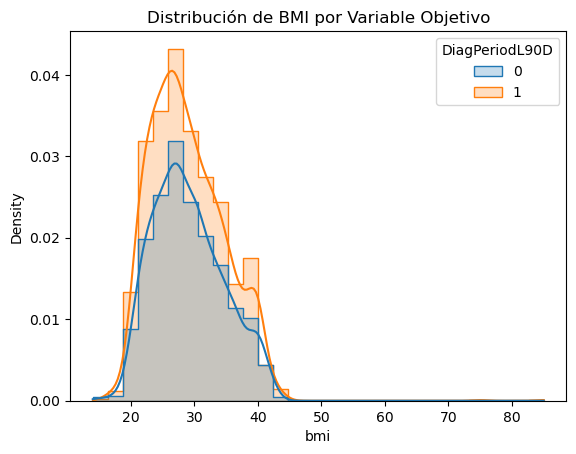

In [9]:
sns.histplot(data=df_training, x='bmi', hue='DiagPeriodL90D', bins=30, kde=True, element='step', stat='density')
plt.title('Distribución de BMI por Variable Objetivo')
plt.show()

In [10]:
## Clasificacion de bmi (indice de masa corporal)
df_training['bmi_category'] = pd.cut(df_training['bmi'], bins=[0, 18.5, 24.9, 29.9, 34.9,39.9, np.inf], labels=['Underweight', 'Normal', 'Overweight', 'Obesity I', 'Obesity II','Extreme']).astype(object)
df_test['bmi_category'] = pd.cut(df_test['bmi'], bins=[0, 18.5, 24.9, 29.9, 34.9,39.9, np.inf], labels=['Underweight', 'Normal', 'Overweight', 'Obesity I', 'Obesity II','Extreme']).astype(object)
df_training['bmi_category'] = df_training['bmi_category'].fillna('Unknown')
df_test['bmi_category'] = df_test['bmi_category'].fillna('Unknown')

In [11]:
df_training.drop(columns=['bmi'], inplace=True) # Elimina la columna original 'bmi' del DataFrame de entrenamiento.
df_test.drop(columns=['bmi'], inplace=True) # Elimina la columna original 'bmi' del DataFrame de prueba.

In [12]:
# la proporcion de cada categoria de bmi en relacion con la variable objetivo:
display(pd.crosstab(df_training['bmi_category'], df_training['DiagPeriodL90D'], normalize='index', margins=True))

DiagPeriodL90D,0,1
bmi_category,,
Extreme,0.410256,0.589744
Normal,0.399600,0.600400
Obesity I,0.430752,0.569248
Obesity II,0.406316,0.593684
Overweight,0.412472,0.587528
Underweight,0.409091,0.590909
Unknown,0.359175,0.640825
All,0.375484,0.624516


In [13]:
# proporcion de la variable objetivo:
print("Proporción Variable Objetivo:")
print(df_training['DiagPeriodL90D'].value_counts(normalize=True))
print("\nHay una desproporcion en los datos de nuestra variable objetivo, se podria aplicar algun metodo para equilibrarlas.")

Proporción Variable Objetivo:
DiagPeriodL90D
1    0.624516
0    0.375484
Name: proportion, dtype: float64

Hay una desproporcion en los datos de nuestra variable objetivo, se podria aplicar algun metodo para equilibrarlas.


#### Tratamiento "patient_race" y "payer_type"

In [14]:
df_training['patient_race'] = df_training['patient_race'].fillna('Unknown')# Rellena los valores nulos en la columna 'patient_race' con 'Unknown'.
df_test['patient_race'] = df_test['patient_race'].fillna('Unknown') # lo mismo para el conjunto de prueba.

df_training['payer_type'] = df_training['payer_type'].fillna('No insurance')# Rellena los valores nulos en la columna 'payer_type' con 'No insurance'.
df_test['payer_type'] = df_test['payer_type'].fillna('No insurance') # lo mismo para el conjunto de prueba.

#### Tratamiento de Nulos Restantes (Train y Test)


Podriamos imputar valores faltantes, pero en esta ocasion eliminare las filas  ya que tienen un porcentaje muy bajo de nulos


In [15]:
null_percentage = (round(df_training.isnull().mean()*100, 2)).to_frame(name='Porcentaje de valores nulos').sort_values(by='Porcentaje de valores nulos', ascending=False)
display(null_percentage.head(20))

,Porcentaje de valores nulos
patient_state,0.40
Division,0.40
Region,0.40
PM25,0.22
N02,0.22
Ozone,0.22
income_household_20_to_25,0.03
home_ownership,0.03
family_dual_income,0.03
family_size,0.03


In [16]:
df_training = df_training.dropna()# Elimina todas las filas que contienen valores nulos en cualquier columna del DataFrame de entrenamiento.
df_test = df_test.dropna() # tambien en test

In [17]:
null_percentage = (round(df_test.isnull().mean()*100,2)).to_frame(name='Porcentaje de valores nulos').sort_values(by='Porcentaje de valores nulos', ascending=False)
display(null_percentage.head(20))

,Porcentaje de valores nulos
patient_race,0.0
payer_type,0.0
patient_state,0.0
patient_zip3,0.0
patient_age,0.0
patient_gender,0.0
breast_cancer_diagnosis_code,0.0
metastatic_cancer_diagnosis_code,0.0
Region,0.0
Division,0.0


## Identificar y eliminar los duplicados

In [18]:
print(f"Duplicados en Train: {df_training.duplicated().sum()}")
print(f"Duplicados en Test: {df_test.duplicated().sum()}")
# los eliminaríamos con:
df_training = df_training.drop_duplicates()
df_test = df_test.drop_duplicates()


Duplicados en Train: 36
Duplicados en Test: 7


In [19]:
# Verificamos:
print(f"Duplicados en Train: {df_training.duplicated().sum()}")
print(f"Duplicados en Test: {df_test.duplicated().sum()}")

Duplicados en Train: 0
Duplicados en Test: 0


## Codificación de variables categoricas

In [20]:
training_categories = df_training.select_dtypes(include=['object']).columns.tolist() # Lista de columnas categóricas en el conjunto de entrenamiento.
training_numeric = df_training.select_dtypes(include=['number']).columns.tolist() # Lista de columnas numéricas en el conjunto de entrenamiento.

# Remover la variable objetivo de la lista numérica si está ahí
if 'DiagPeriodL90D' in training_numeric:
    training_numeric.remove('DiagPeriodL90D')
    
print(f"Columnas Categóricas ({len(training_categories)}): {training_categories}")
print(f"Columnas Numéricas ({len(training_numeric)}): {training_numeric}")

Columnas Categóricas (9): ['patient_race', 'payer_type', 'patient_state', 'patient_gender', 'breast_cancer_diagnosis_code', 'metastatic_cancer_diagnosis_code', 'Region', 'Division', 'bmi_category']
Columnas Numéricas (69): ['patient_zip3', 'patient_age', 'population', 'density', 'age_median', 'age_under_10', 'age_10_to_19', 'age_20s', 'age_30s', 'age_40s', 'age_50s', 'age_60s', 'age_70s', 'age_over_80', 'male', 'female', 'married', 'divorced', 'never_married', 'widowed', 'family_size', 'family_dual_income', 'income_household_median', 'income_household_under_5', 'income_household_5_to_10', 'income_household_10_to_15', 'income_household_15_to_20', 'income_household_20_to_25', 'income_household_25_to_35', 'income_household_35_to_50', 'income_household_50_to_75', 'income_household_75_to_100', 'income_household_100_to_150', 'income_household_150_over', 'income_household_six_figure', 'income_individual_median', 'home_ownership', 'housing_units', 'home_value', 'rent_median', 'rent_burden', 'e

In [21]:
df_training_encoded = pd.get_dummies(df_training, columns=training_categories, drop_first=False, dtype=int)# Codificación one-hot
df_test_encoded = pd.get_dummies(df_test, columns=training_categories, drop_first=False, dtype=int)# Codificación one-hot

In [22]:
# Alinear las columnas del DataFrame de prueba con las de entrenamiento (X)
X = df_training_encoded.drop(columns=['DiagPeriodL90D'])
y = df_training_encoded['DiagPeriodL90D']

train_cols = X.columns
df_test_aligned = df_test_encoded.reindex(columns=train_cols, fill_value=0)

# verificar que ahora tienen el mismo número de columnas
print(f"Columnas en X (entrenamiento): {X.shape[1]}")
print(f"Columnas en el set de prueba alineado: {df_test_aligned.shape[1]}")

Columnas en X (entrenamiento): 240
Columnas en el set de prueba alineado: 240


Revisión de valores únicos y categorías
Algunas variables no comparten valores únicos entre los distintos datasets (por ejemplo, estado de residencia o código de cáncer)
¿Cómo solucionarías esto?

La solución es alineal el dataframe de testal de train:

Se obtiene la lista de columnas final deldf_training codificado.

Se usa el método.reindex() en el df_testcodificado, pasándole la lista de columnas de train.

Se especificafill_value=0 .

## Analisis Exploratorio (EDA) - General

In [23]:
# ver y almacenar un resumen descriptivo de las columnas
desc = pd.DataFrame(index = list(df_training.columns))
desc['type'] = df_training.dtypes
desc['count'] = df_training.count()
desc['nunique'] = df_training.nunique()
desc['%unique'] = desc['nunique'] /len(df_training) * 100
desc['null'] = df_training.isnull().sum() # Debería ser 0 ahora
desc['%null'] = desc['null'] / len(df_training) * 100
desc = pd.concat([desc,df_training.describe().T.drop('count',axis=1)],axis=1)

display(desc.sort_values(by=['type','null']).style.background_gradient(axis=0))

,type,count,nunique,%unique,null,%null,mean,std,min,25%,50%,75%,max
patient_zip3,int64,12786,731,5.717191,0,0.000000,572.831378,274.949721,101.000000,331.000000,554.000000,840.000000,994.000000
patient_age,int64,12786,67,0.524011,0,0.000000,59.161270,13.337024,18.000000,50.000000,59.000000,67.000000,91.000000
DiagPeriodL90D,int64,12786,2,0.015642,0,0.000000,0.624511,0.484268,0.000000,0.000000,1.000000,1.000000,1.000000
population,float64,12786,731,5.717191,0,0.000000,20763.942932,13911.005023,635.545455,9463.896552,19154.190480,30021.278690,71374.131580
density,float64,12786,731,5.717191,0,0.000000,1582.416692,2968.941492,0.916667,170.550000,700.337500,1666.515385,21172.000000
age_median,float64,12786,721,5.638980,0,0.000000,40.509372,4.030426,28.875000,37.129825,40.639344,42.934783,54.570000
age_under_10,float64,12786,711,5.560770,0,0.000000,11.128981,1.496767,5.218519,10.160000,11.039216,12.193750,17.675000
age_10_to_19,float64,12786,718,5.615517,0,0.000000,12.945731,1.894138,6.314286,11.741176,12.932609,14.021739,29.575000
age_20s,float64,12786,717,5.607696,0,0.000000,13.260032,3.199536,5.925000,11.013415,12.538095,14.971053,32.800000
age_30s,float64,12786,718,5.615517,0,0.000000,12.864709,2.316131,5.693333,11.292105,12.442647,14.037838,25.471429


In [24]:
# Distribución de Variables numeric
num_cols = df_training.select_dtypes('number').columns.tolist()
target = 'DiagPeriodL90D'
if target in num_cols:
    num_cols.remove(target)

fig, ax = plt.subplots(math.ceil(len(num_cols)/6), 6, figsize=(25,25), dpi=300)
ax = ax.flatten()

for i, col in enumerate(num_cols):
  sns.kdeplot(df_training[col],ax=ax[i],color='b', fill=True)
  ax[i].set_title(f'{col}')
  ax[i].set_xlabel(None) 

for j in range(len(num_cols),len(ax)):
  ax[j].axis('off')

fig.suptitle('Distribution of Numeric Features (Train)', fontsize = 24, fontweight = 'bold')
plt.tight_layout(h_pad=0.1, w_pad=0.5, rect=[0, 0.03, 1, 0.97])
plt.show()

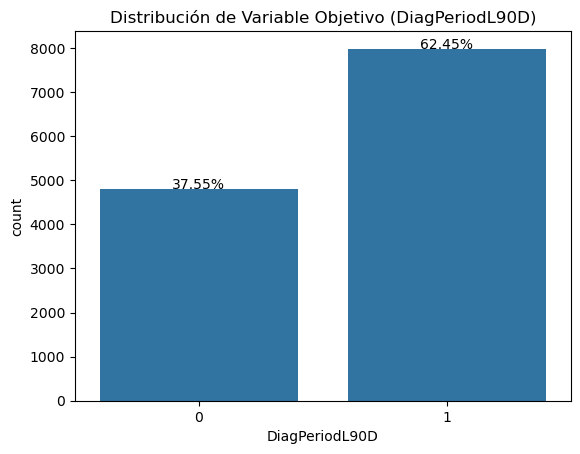

In [25]:
# Distribución de Variable Objetivo
ax = sns.countplot(x=df_training['DiagPeriodL90D'])
total = len(df_training['DiagPeriodL90D'])
for p in ax.patches:
  height = p.get_height()
  ax.text(p.get_x() + p.get_width() / 2., height + 0.1,
         '{:.2%}'.format(height / total),
         ha="center")
plt.title('Distribución de Variable Objetivo (DiagPeriodL90D)')
plt.show()

C:\Users\alda09\AppData\Local\Temp\ipykernel_5908\3061492266.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=90, ha='right',fontsize='small')
C:\Users\alda09\AppData\Local\Temp\ipykernel_5908\3061492266.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=90, ha='right',fontsize='small')
C:\Users\alda09\AppData\Local\Temp\ipykernel_5908\3061492266.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=90, ha='right',fontsize='small')
C:\Users\alda09\AppData\Local\Temp\ipykernel_5908\3061492266.py:12: UserWarning: set_ticklabels() should only be used with a fixed number o

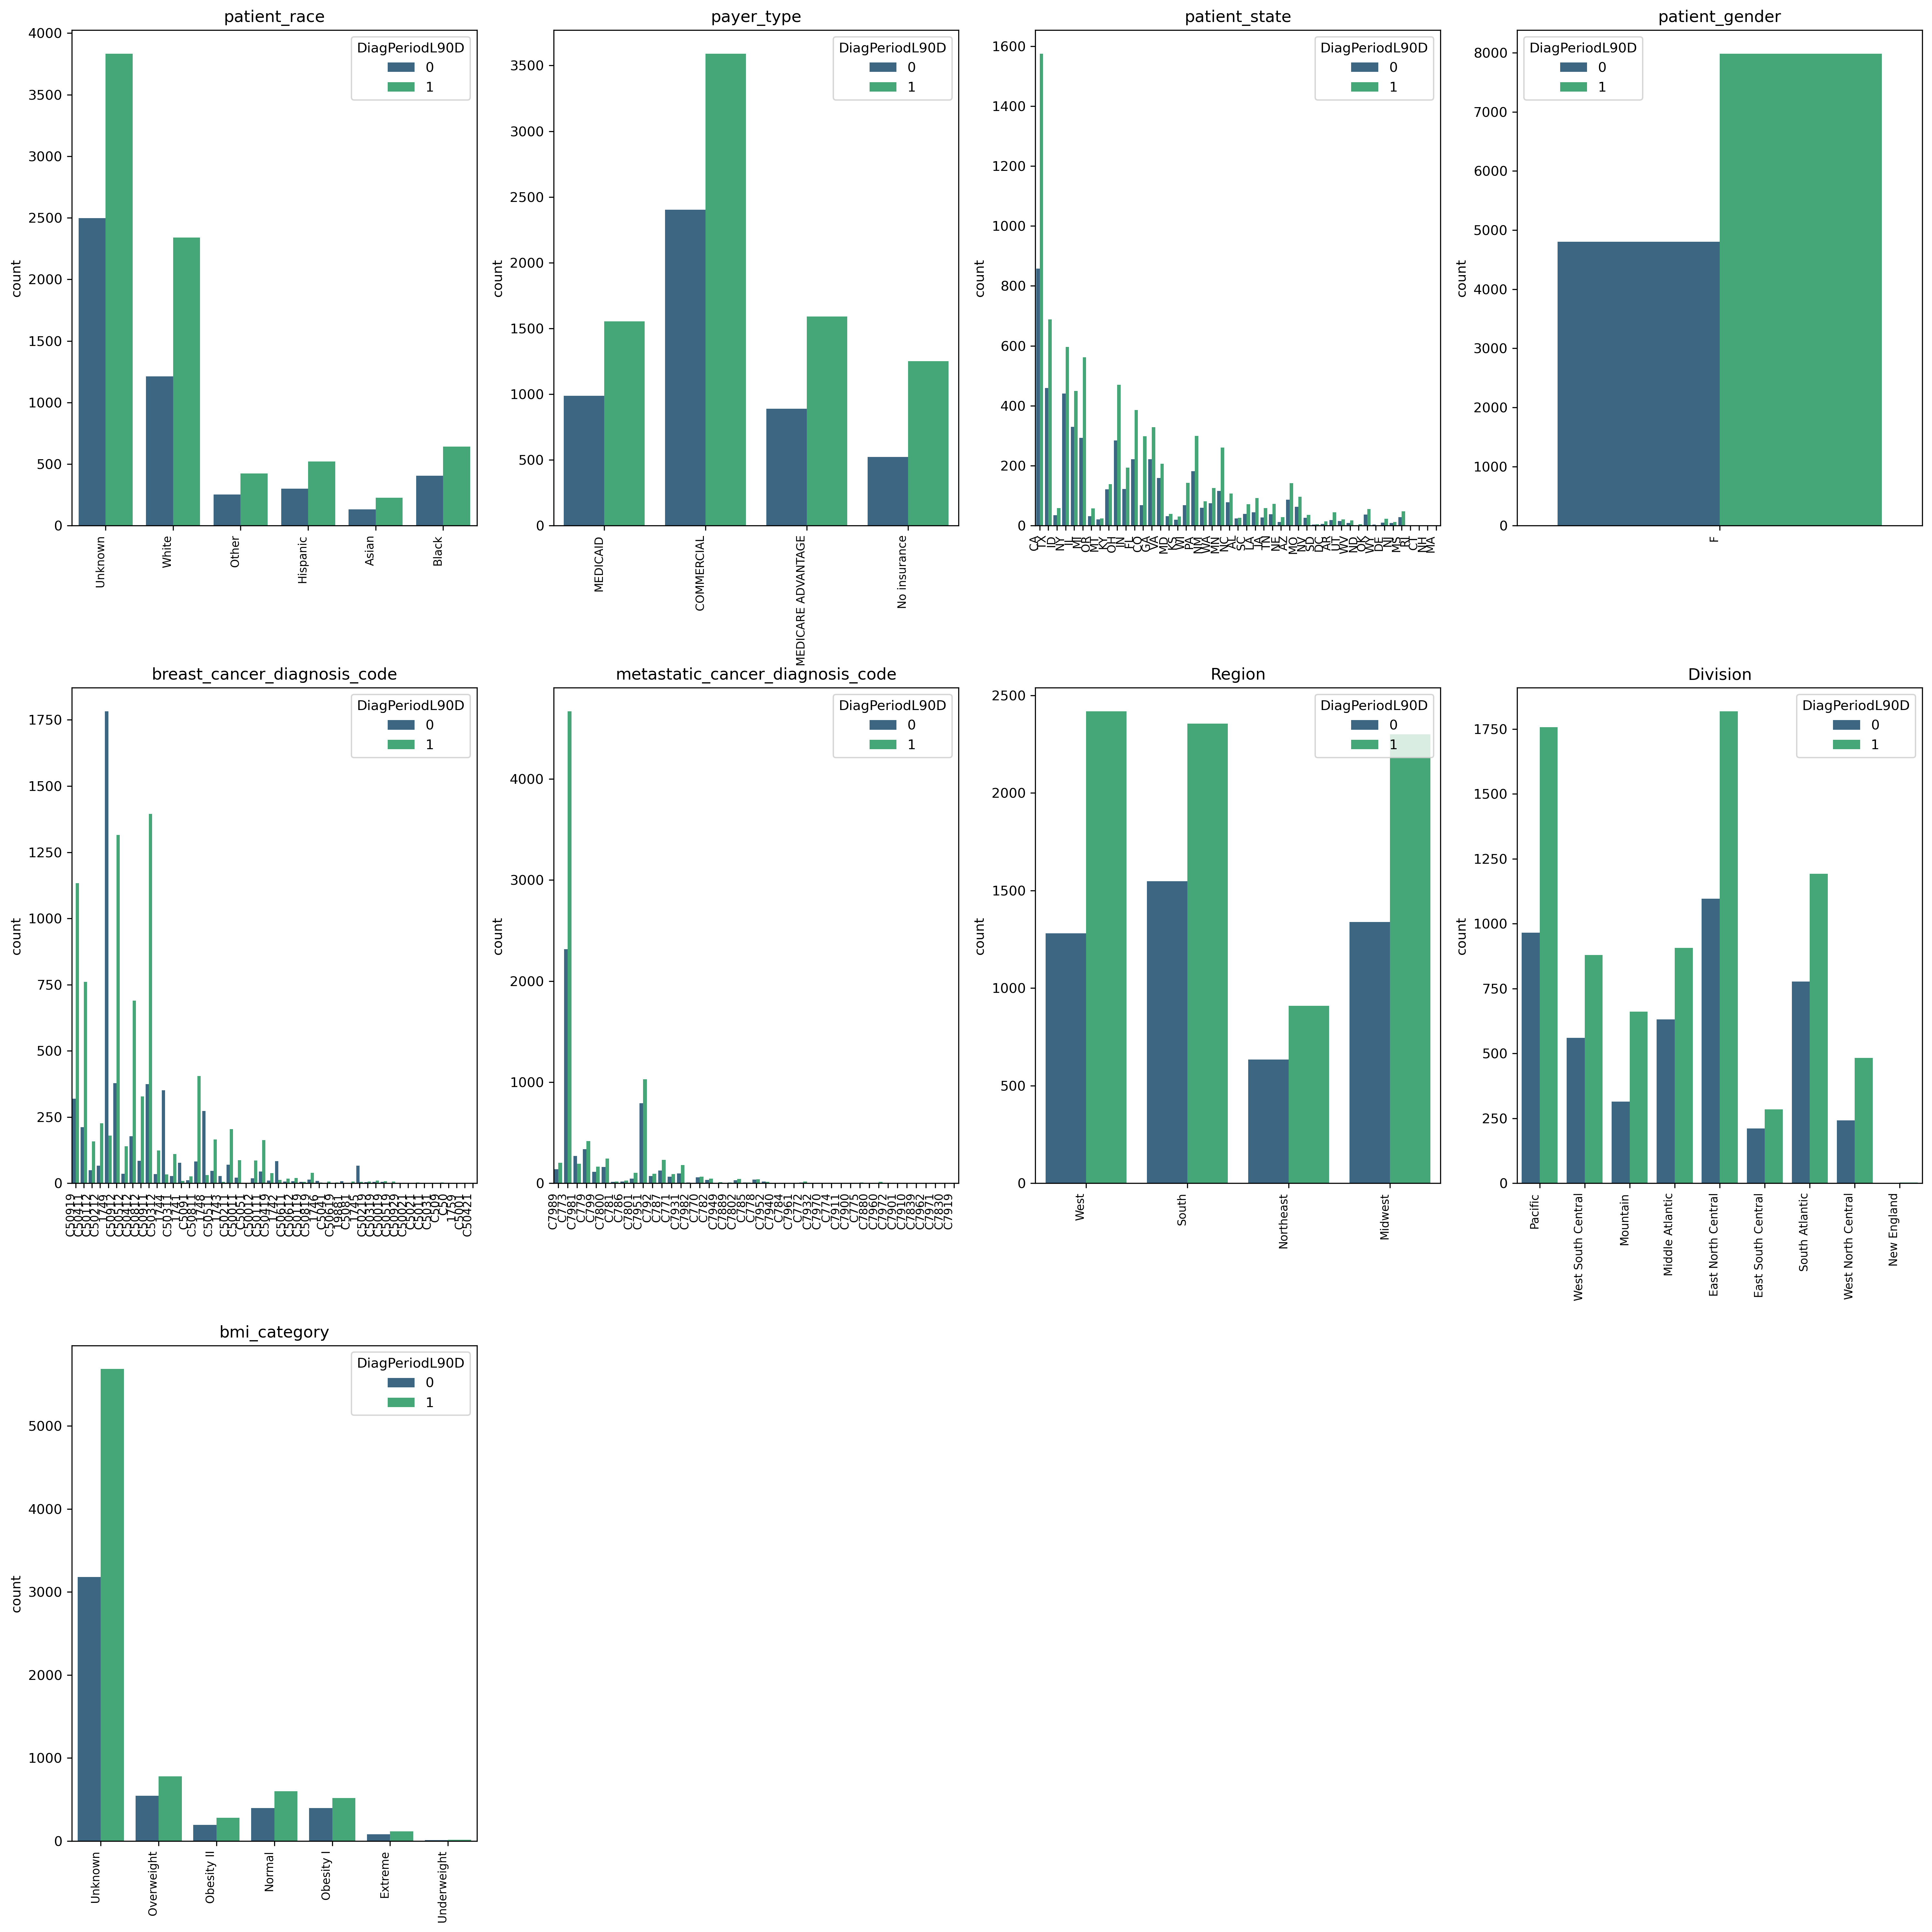

In [26]:
# Distribución de Variables Categóricas (pre-codificación)
cat_cols = df_training.select_dtypes('object').columns.tolist()

fig, ax = plt.subplots(math.ceil(len(cat_cols)/4), 4, figsize=(20,20), dpi=300)
ax = ax.flatten()
plt.subplots_adjust(wspace=0.3, hspace=0.5)

for i, col in enumerate(cat_cols):
  sns.countplot(x=df_training[col],hue=df_training[target],ax=ax[i], palette='viridis')
  ax[i].set_title(f'{col}')
  ax[i].set_xlabel(None)
  ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=90, ha='right',fontsize='small')

for j in range(len(cat_cols),len(ax)):
  ax[j].axis('off')

plt.tight_layout(h_pad=0.1)
plt.show()

##  Analisis de Equidad: Tasa de Diagnóstico vs. Grupos Demograficos


In [27]:
def plot_rate_by_group(df, column_name):
    """
    Calcula y grafica la tasa de 'DiagPeriodL90D == 1' para cada categoría
    en la columna especificada.
    """
    # 1. Calcular la proporción de '1' (tasa de diagnóstico positivo)
    # normalize='index' es la clave
    proportions = pd.crosstab(df[column_name], df['DiagPeriodL90D'], normalize='index')
    
    # Ordenar por la tasa de positivos (columna 1)
    proportions = proportions.sort_values(by=1, ascending=False)
    
    print(f"--- Análisis de Tasa de Diagnóstico para: {column_name} ---")
    print(proportions.applymap(lambda x: f"{x:.2%}"))
    print("\n")
    
    # 3. Graficar
    ax = proportions.plot(kind='bar', 
                          stacked=True, 
                          figsize=(12, 6), 
                          colormap='viridis',
                          title=f'Tasa de Diagnóstico Positivo (1) por {column_name}')
    
    ax.legend(title='DiagPeriodL90D', labels=['No (0)', 'Sí (1)'], bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.set_xlabel(column_name)
    ax.set_ylabel('Proporción')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y))) 
    
    # Añadir etiquetas de porcentaje para la clase '1' (la porción superior)
    for p in ax.patches:
        width, height = p.get_width(), p.get_height()
        x, y = p.get_x(), p.get_y()
        
        # Solo etiquetar la porción de la clase '1'
        if y > 0.5 and height > 0.01: # Asumiendo que clase 1 está apilada encima
             ax.annotate(f'{height:.1%}', (x + width / 2., y + height / 2.), 
                         ha='center', va='center', color='white', fontweight='bold', fontsize=9)
    
    plt.tight_layout()
    plt.show()

--- Análisis de Tasa de Diagnóstico para: patient_race ---
DiagPeriodL90D       0       1
patient_race                  
White           34.12%  65.88%
Asian           36.59%  63.41%
Hispanic        36.66%  63.34%
Other           37.52%  62.48%
Black           38.68%  61.32%
Unknown         39.46%  60.54%




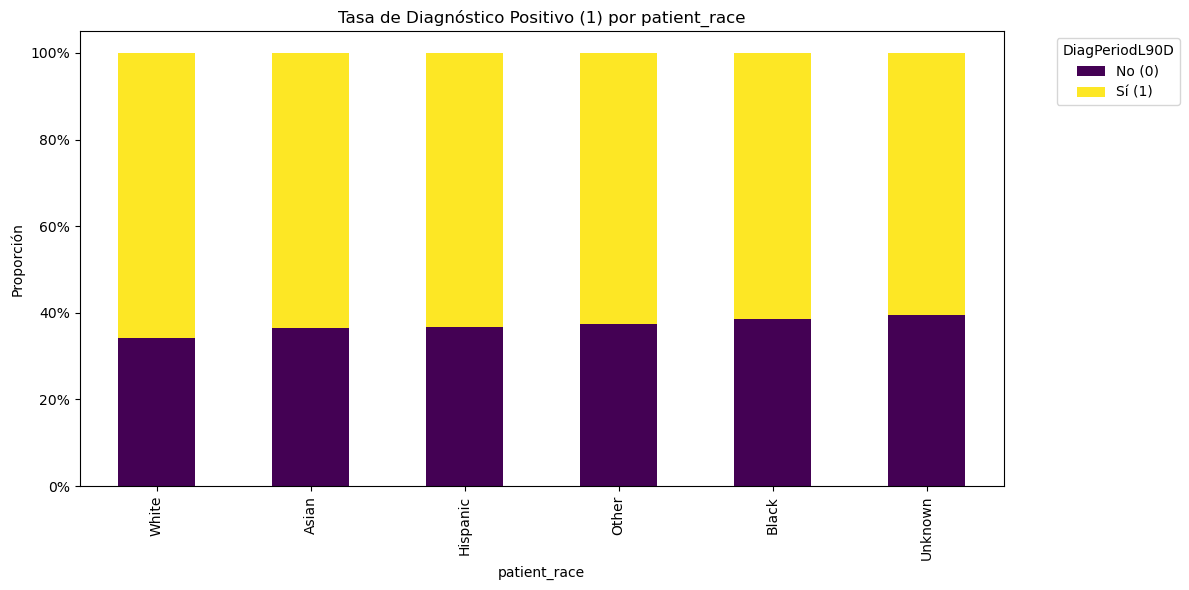

In [28]:
# Análisis por Raza del Paciente
plot_rate_by_group(df_training, 'patient_race')

--- Análisis de Tasa de Diagnóstico para: payer_type ---
DiagPeriodL90D           0       1
payer_type                        
No insurance        29.44%  70.56%
MEDICARE ADVANTAGE  35.82%  64.18%
MEDICAID            38.86%  61.14%
COMMERCIAL          40.11%  59.89%




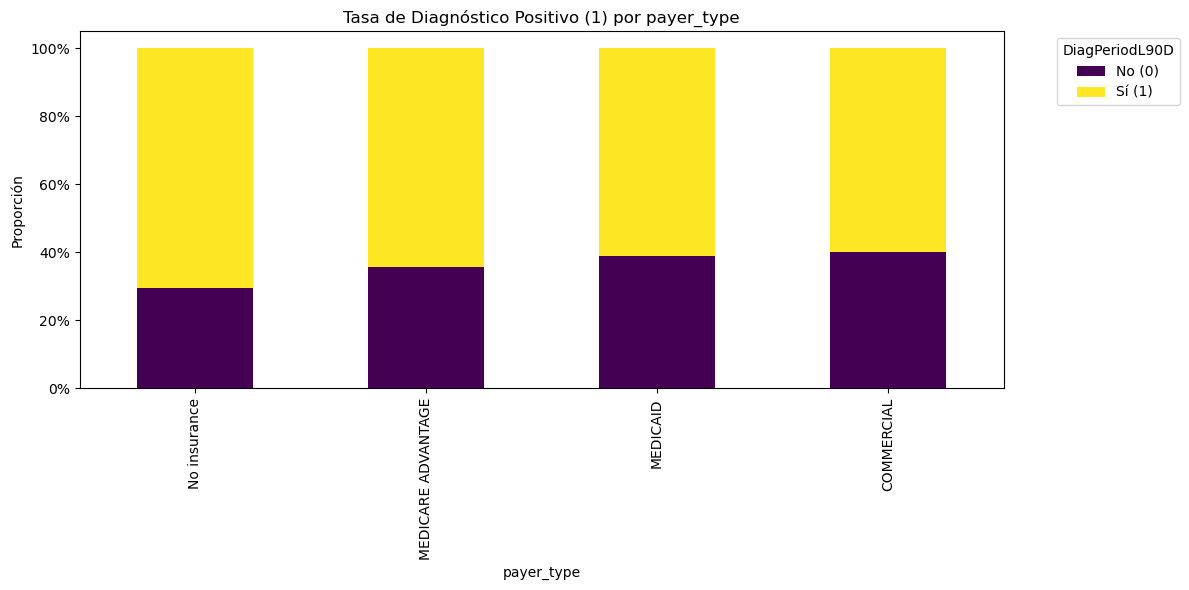

In [29]:
#Análisis por Tipo de Seguro
plot_rate_by_group(df_training, 'payer_type')

--- Análisis de Tasa de Diagnóstico para: bmi_category ---
DiagPeriodL90D       0       1
bmi_category                  
Unknown         35.88%  64.12%
Normal          39.96%  60.04%
Obesity II      40.80%  59.20%
Underweight     40.91%  59.09%
Overweight      41.19%  58.81%
Extreme         41.24%  58.76%
Obesity I       43.31%  56.69%




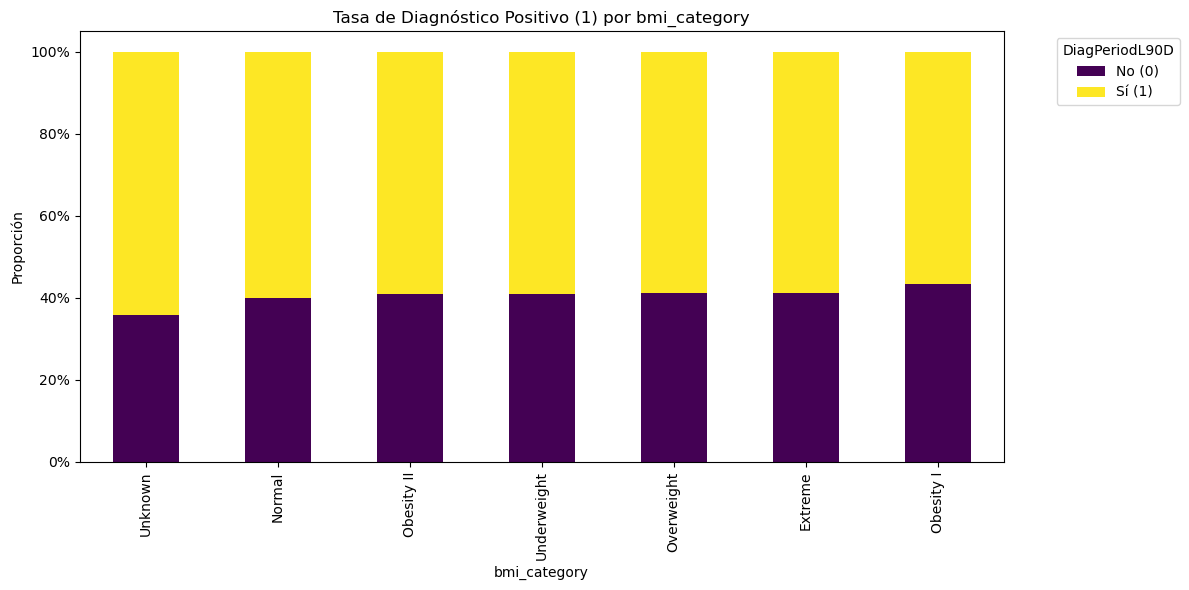

In [30]:
#Analisis por Categoría de BMI
plot_rate_by_group(df_training, 'bmi_category')

--- Análisis de Tasa de Diagnóstico para: Region ---
DiagPeriodL90D       0       1
Region                        
West            34.61%  65.39%
Midwest         36.79%  63.21%
South           39.65%  60.35%
Northeast       41.06%  58.94%




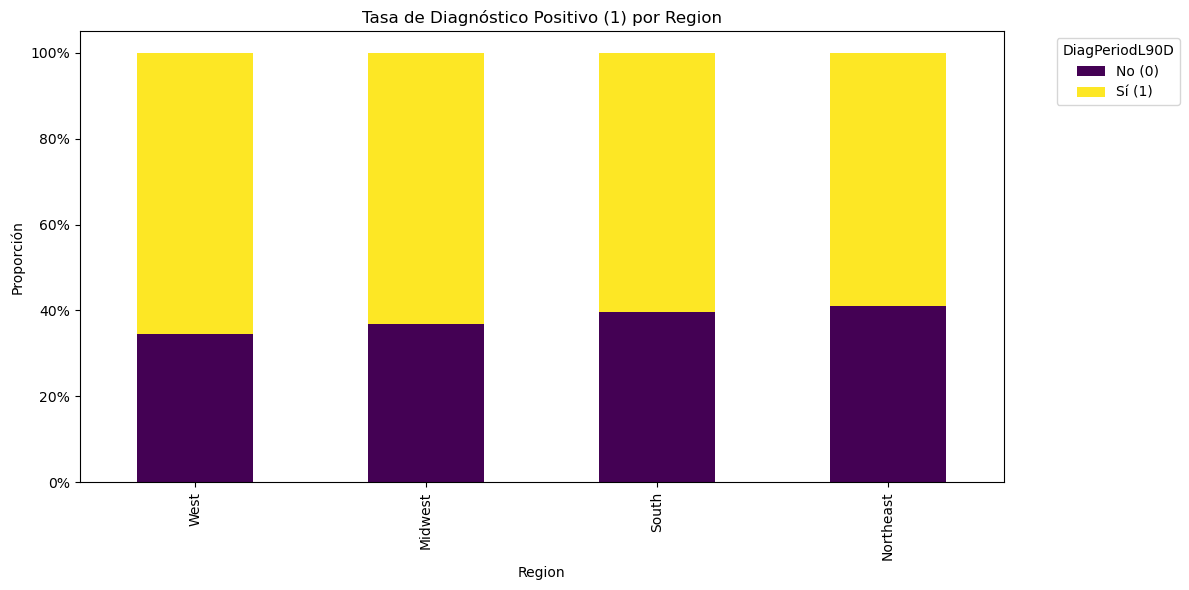

In [31]:
# Analisis de "region"
plot_rate_by_group(df_training, 'Region')

### Análisis de Distribución Numérica por Variable Objetivo

Analizamos si las distribuciones de variables numéricas clave difieren
entre los pacientes con diagnóstico positivo (1) y negativo (0).

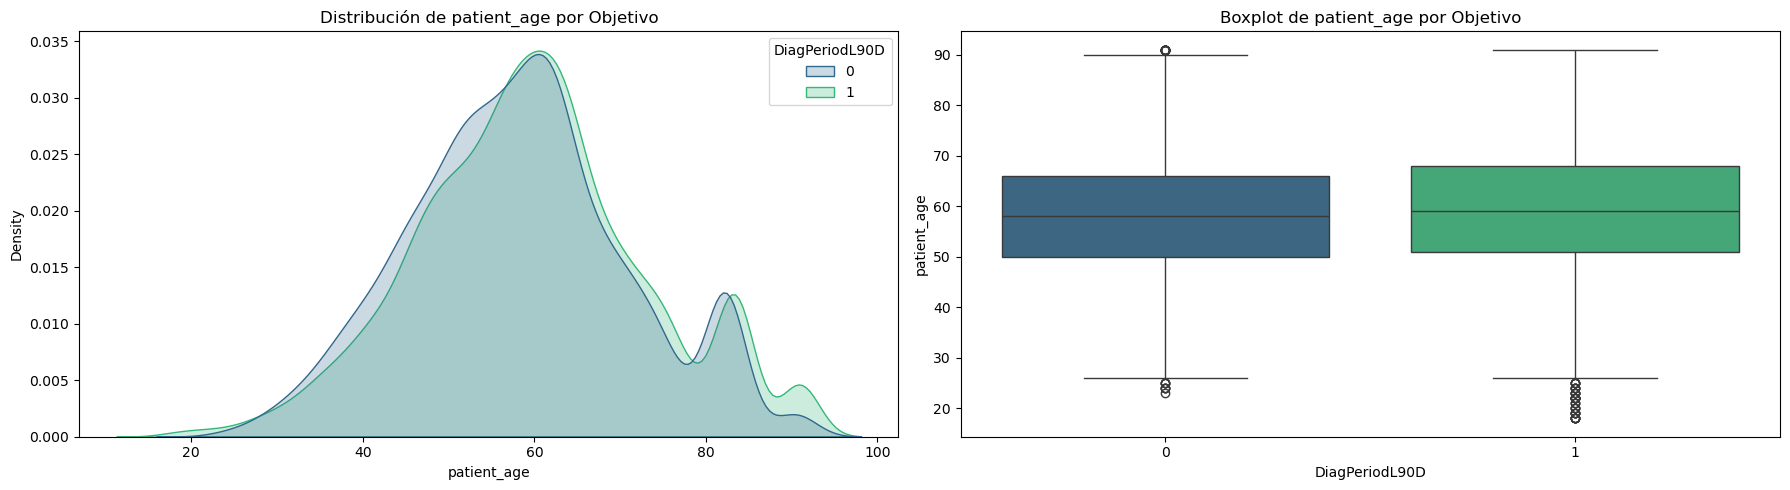

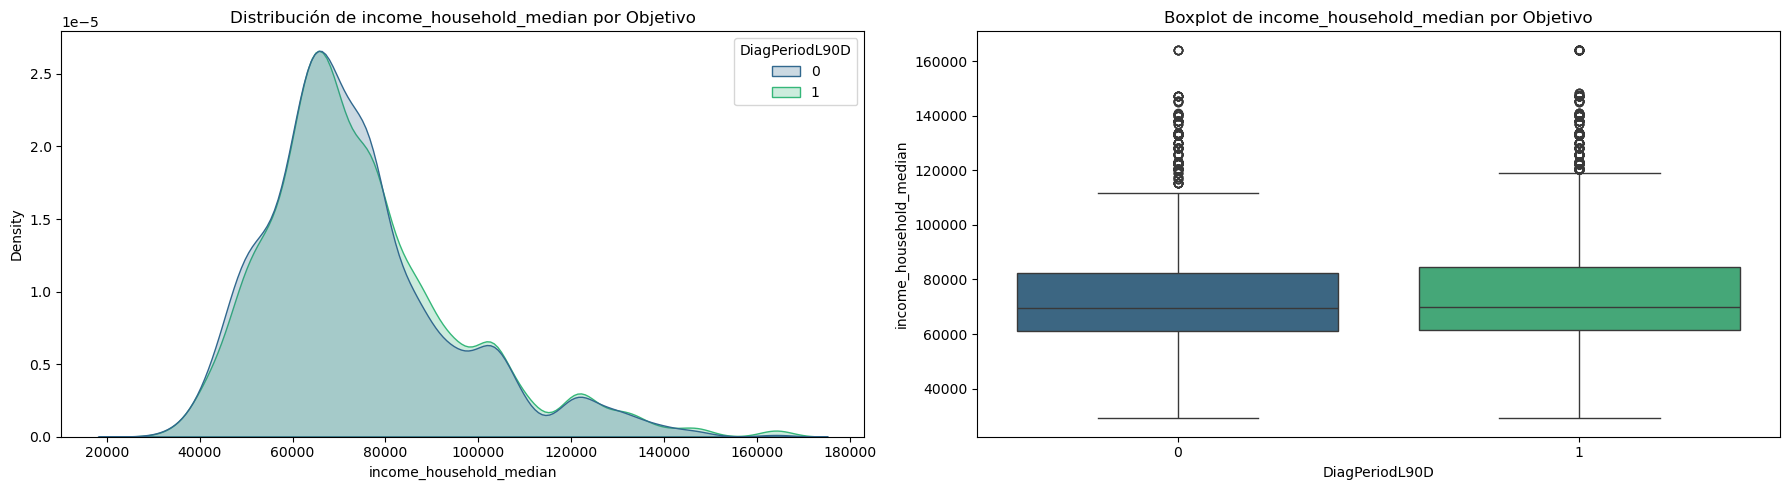

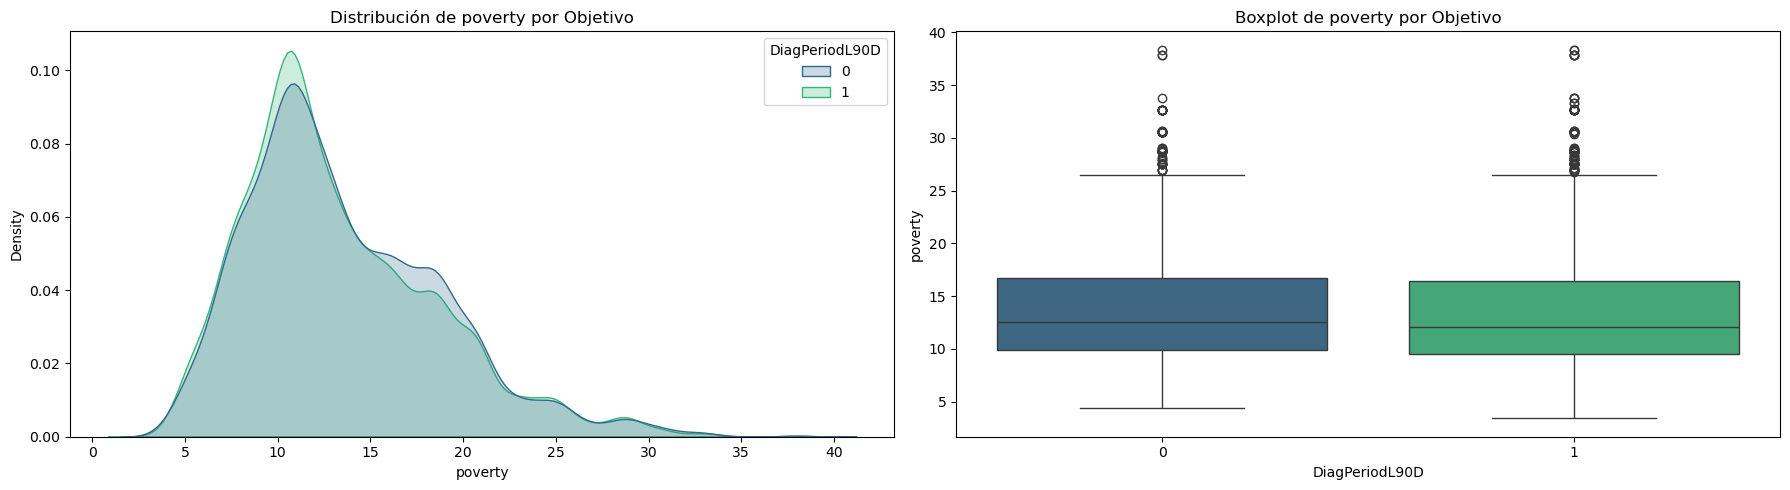

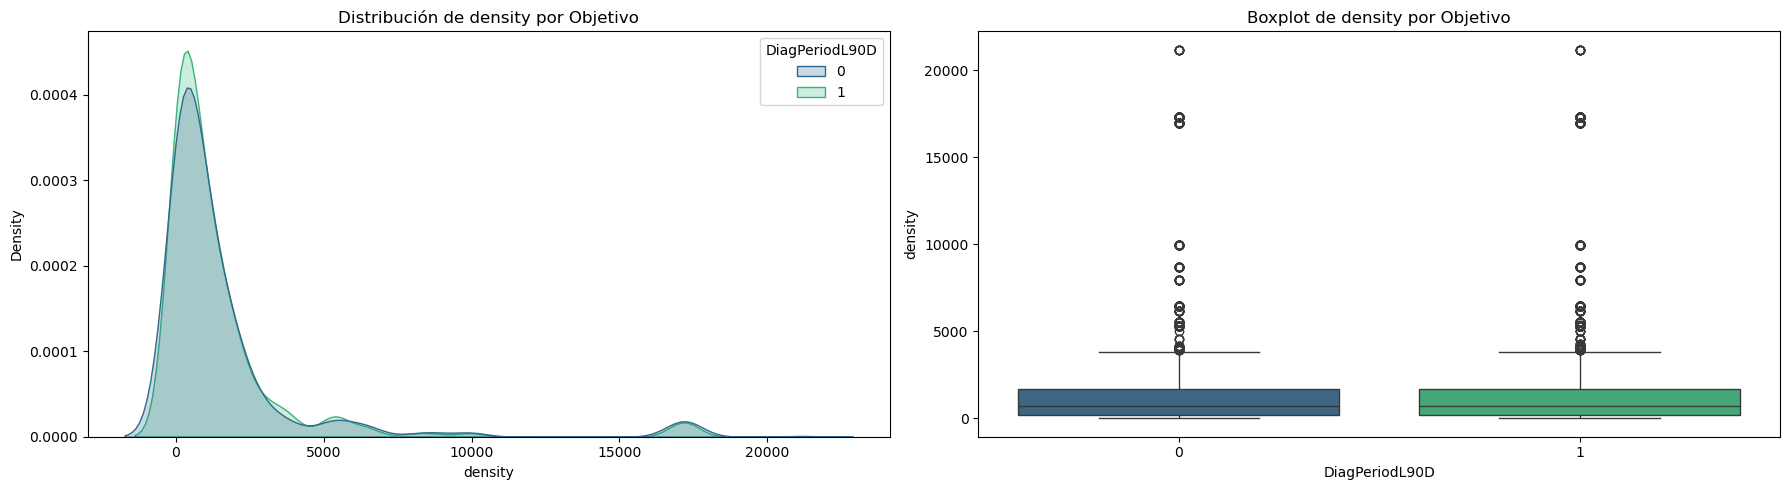

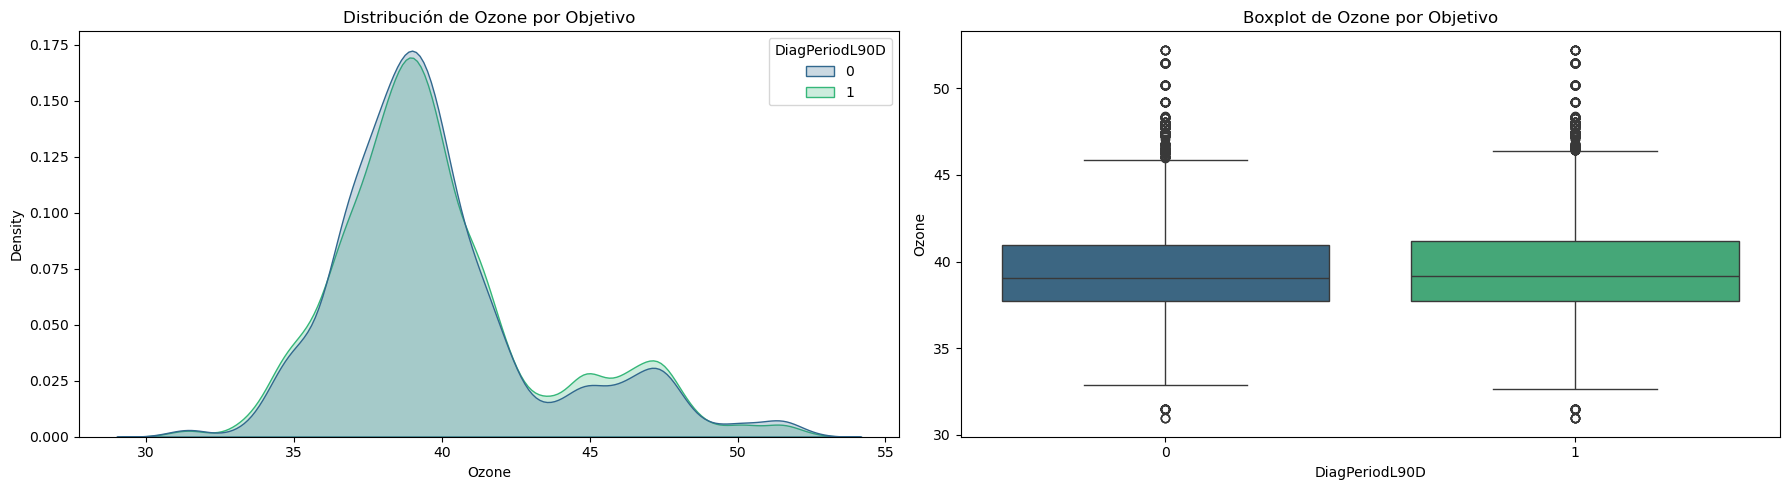

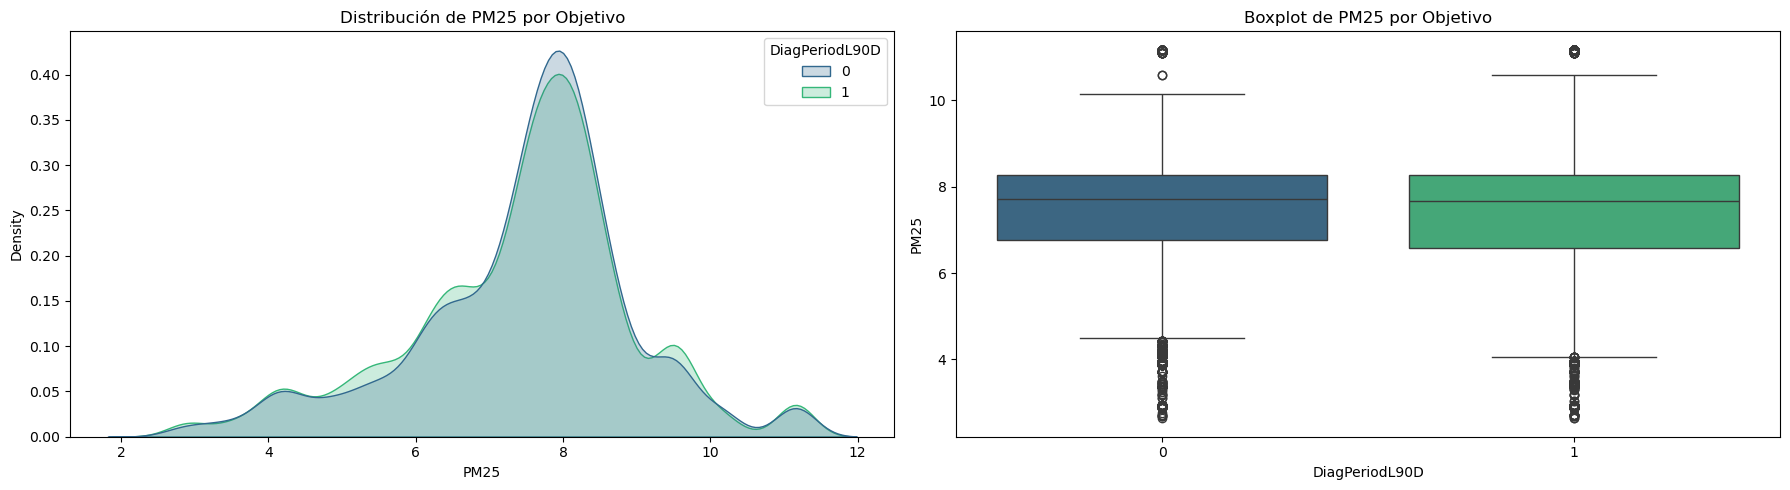

In [32]:
variables_a_analizar = [
  'patient_age',
  'income_household_median',
  'poverty',
  'density',
  'Ozone',
  'PM25'
]

for col in variables_a_analizar:
    plt.figure(figsize=(18, 5))
    
    # 1. Histograma/KDE Plot separado por objetivo
    plt.subplot(1, 2, 1)
    sns.kdeplot(data=df_training, x=col, hue='DiagPeriodL90D', 
                fill=True, common_norm=False, palette='viridis')
    plt.title(f'Distribución de {col} por Objetivo')
    
    # 2. Boxplot separado por objetivo
    plt.subplot(1, 2, 2)
    sns.boxplot(data=df_training, x='DiagPeriodL90D', y=col, palette='viridis')
    plt.title(f'Boxplot de {col} por Objetivo')
    
    plt.tight_layout()
    plt.show()

### Ver outlies

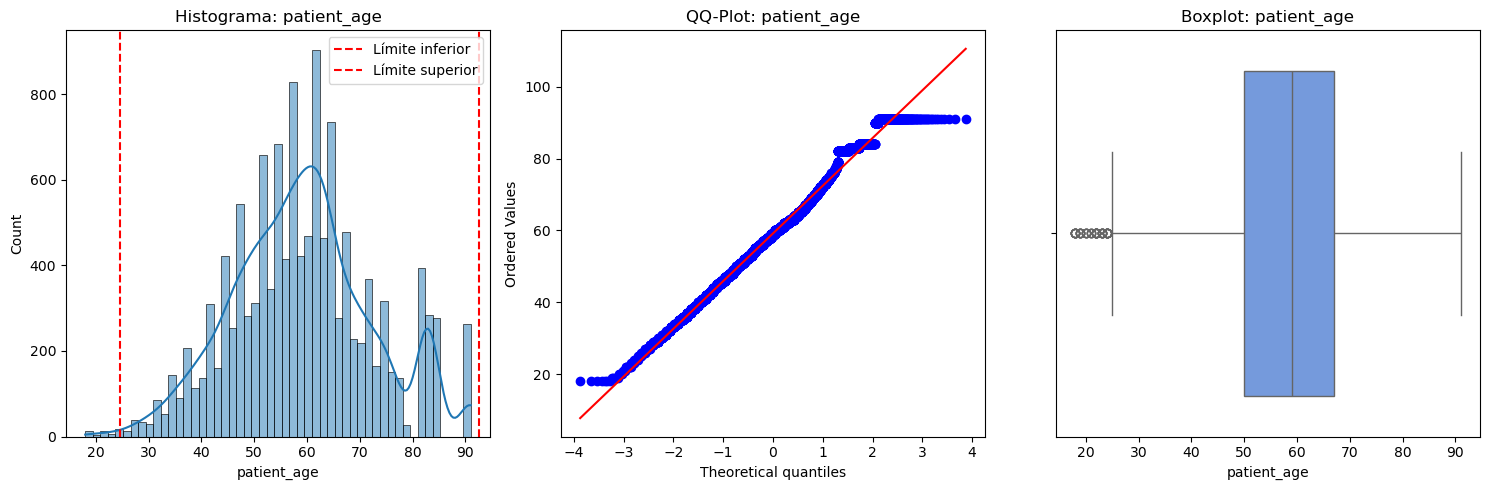

c:\Users\alda09\.conda\envs\mi_env\lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 12786.
  res = hypotest_fun_out(*samples, **kwds)


🔍 Prueba de Shapiro-Wilk para "patient_age":
Estadístico W = 0.991, p-valor = 0.000
⚠️ Probablemente no sigue una distribución normal.



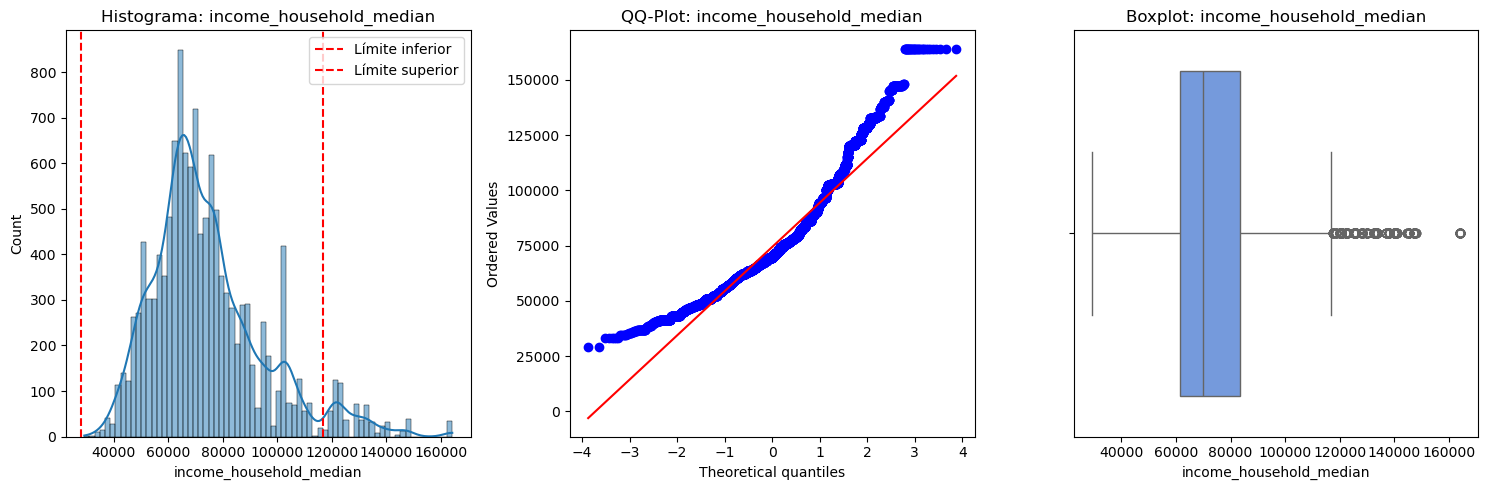

c:\Users\alda09\.conda\envs\mi_env\lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 12786.
  res = hypotest_fun_out(*samples, **kwds)


🔍 Prueba de Shapiro-Wilk para "income_household_median":
Estadístico W = 0.931, p-valor = 0.000
⚠️ Probablemente no sigue una distribución normal.



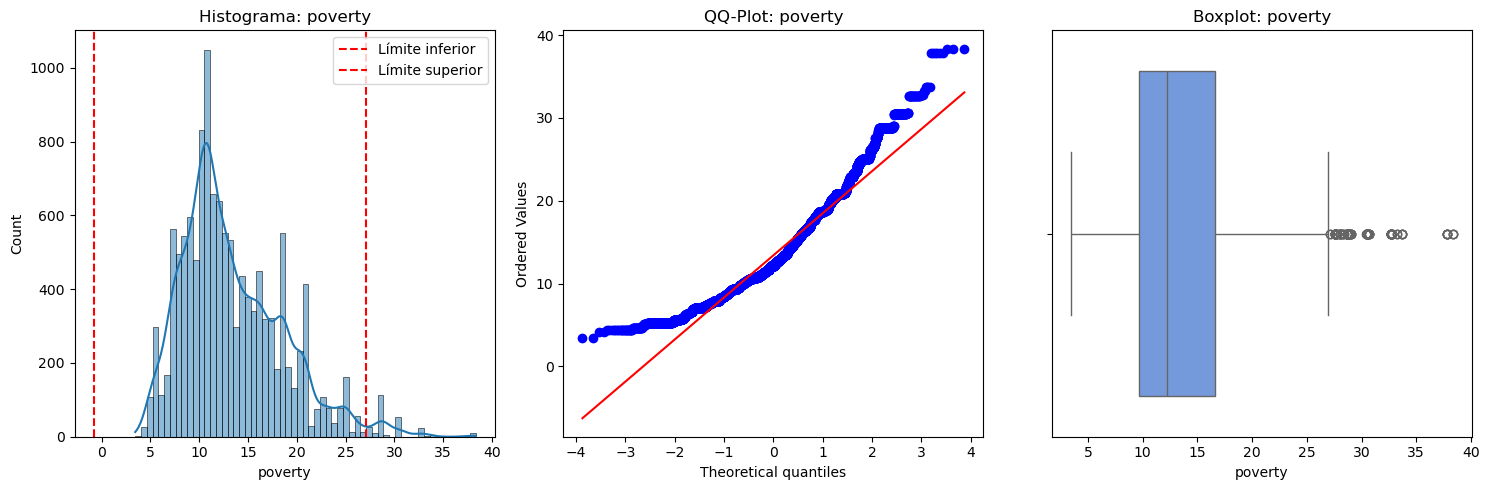

c:\Users\alda09\.conda\envs\mi_env\lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 12786.
  res = hypotest_fun_out(*samples, **kwds)


🔍 Prueba de Shapiro-Wilk para "poverty":
Estadístico W = 0.945, p-valor = 0.000
⚠️ Probablemente no sigue una distribución normal.



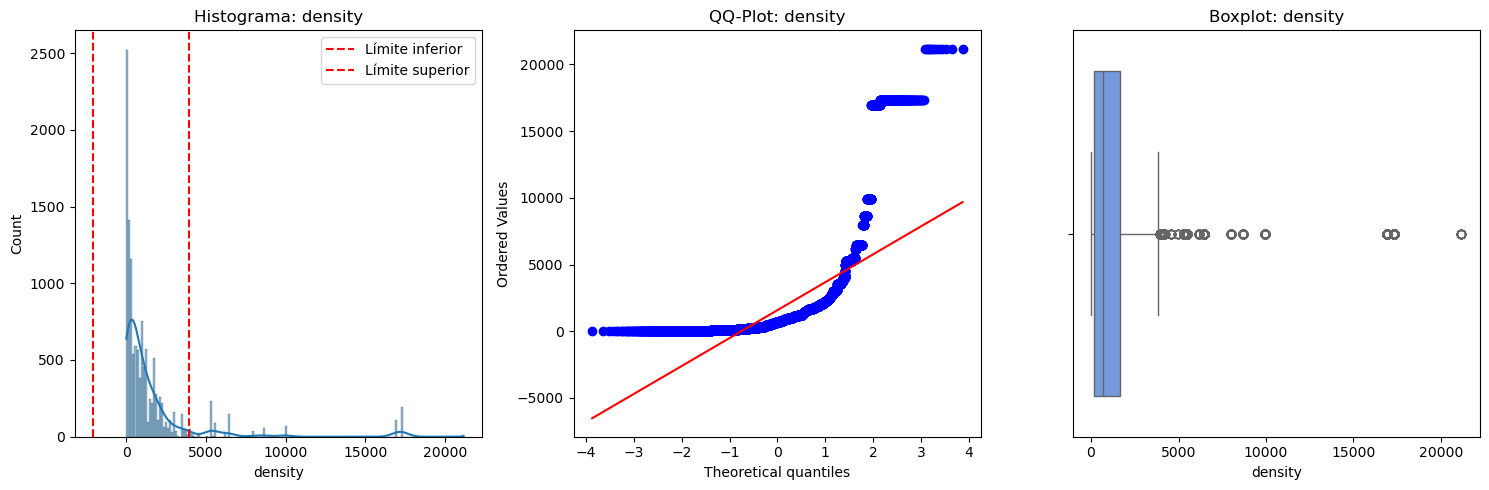

c:\Users\alda09\.conda\envs\mi_env\lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 12786.
  res = hypotest_fun_out(*samples, **kwds)


🔍 Prueba de Shapiro-Wilk para "density":
Estadístico W = 0.497, p-valor = 0.000
⚠️ Probablemente no sigue una distribución normal.



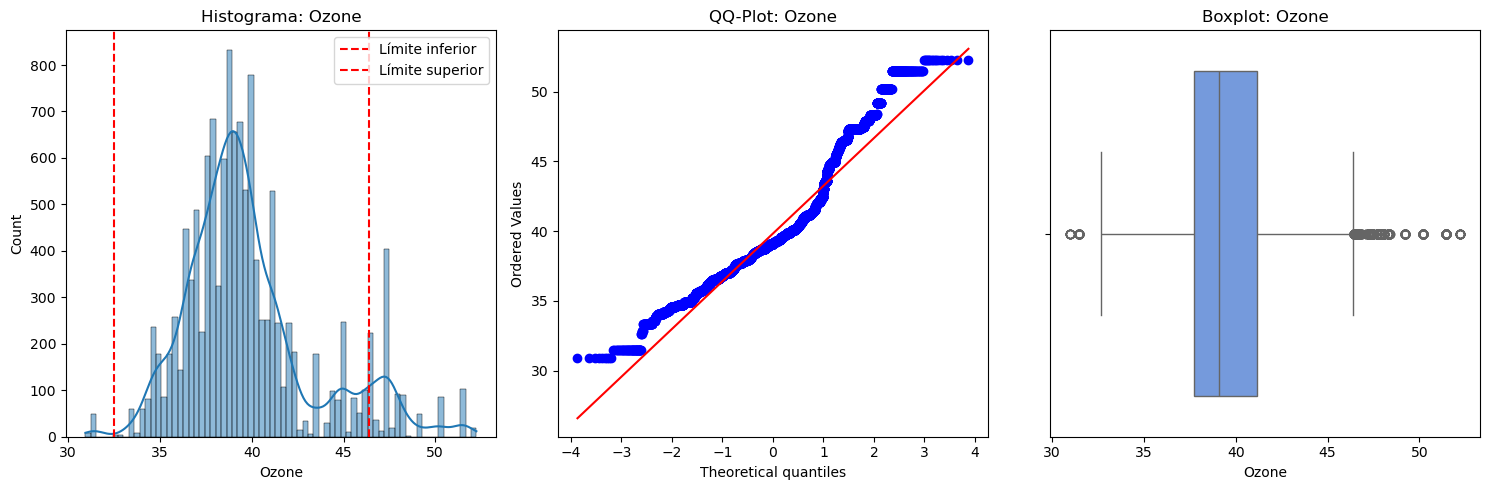

c:\Users\alda09\.conda\envs\mi_env\lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 12786.
  res = hypotest_fun_out(*samples, **kwds)


🔍 Prueba de Shapiro-Wilk para "Ozone":
Estadístico W = 0.922, p-valor = 0.000
⚠️ Probablemente no sigue una distribución normal.



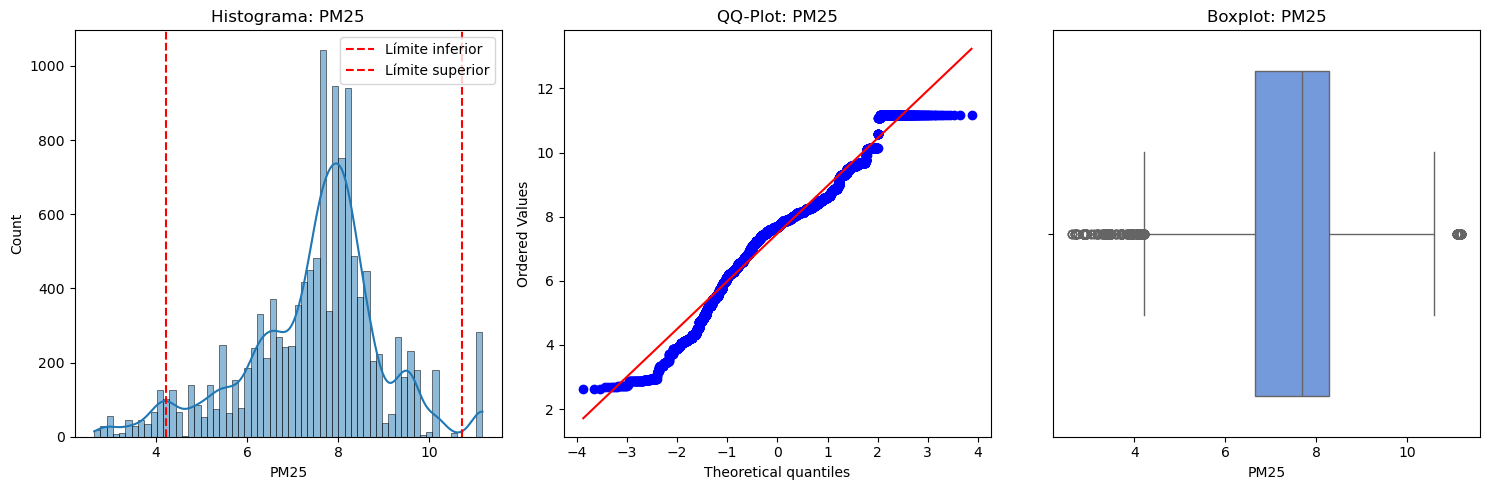

🔍 Prueba de Shapiro-Wilk para "PM25":
Estadístico W = 0.964, p-valor = 0.000
⚠️ Probablemente no sigue una distribución normal.



c:\Users\alda09\.conda\envs\mi_env\lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 12786.
  res = hypotest_fun_out(*samples, **kwds)


In [33]:

# crear un df numerico
numeric_df = df_training.select_dtypes(include='number')
dataframe = numeric_df.copy()

# Nivel de significancia para la prueba de Shapiro-Wilk
significance = 0.05


# Selecciona solo columnas numéricas
numeric_cols = dataframe.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = dataframe.select_dtypes(include=[np.number]).columns.tolist()

# Diccionario para guardar resultados de Shapiro-Wilk
shapiro_results = {}
variables_a_analizar = [
    'patient_age',
    'income_household_median',
    'poverty',
    'density',
    'Ozone',
    'PM25'
]
for col in variables_a_analizar:
    # Definir los umbrales para valores atípicos usando el método de los cuartiles (IQR)
    Q1 = dataframe[col].quantile(0.25)
    Q3 = dataframe[col].quantile(0.75)
    IQR = Q3 - Q1
    threshold_low = Q1 - 1.5 * IQR
    threshold_high = Q3 + 1.5 * IQR

    plt.figure(figsize=(15, 5))

    # Histograma con líneas de umbral
    plt.subplot(1, 3, 1)
    sns.histplot(data=dataframe[col], kde=True)
    plt.axvline(x=threshold_low, color='red', linestyle='--', label='Límite inferior')
    plt.axvline(x=threshold_high, color='red', linestyle='--', label='Límite superior')
    plt.title(f'Histograma: {col}')
    plt.legend()

    # QQ-plot
    plt.subplot(1, 3, 2)
    stats.probplot(dataframe[col].dropna(), dist="norm", plot=plt)
    plt.title(f'QQ-Plot: {col}')

    # Box plot
    plt.subplot(1, 3, 3)
    sns.boxplot(x=dataframe[col], color="cornflowerblue")
    plt.title(f'Boxplot: {col}')

    plt.tight_layout()
    plt.show()

    # Prueba de normalidad de Shapiro-Wilk
    standardized_var = stats.zscore(dataframe[col].dropna())
    stat, p = stats.shapiro(standardized_var)

    print(f'🔍 Prueba de Shapiro-Wilk para "{col}":')
    print(f'Estadístico W = {stat:.3f}, p-valor = {p:.3f}')
    if p > significance:
        print('✅ Probablemente sigue una distribución normal.\n')
    else:
        print('⚠️ Probablemente no sigue una distribución normal.\n')

    # Guardar resultados
    shapiro_results[col] = {'W': stat, 'p-value': p}

De momento no aremos tratamiento de outlies

### Normalización

Aplicamos Standard Scaler a las columnas numéricas. Usaremos el df_training_encoded.

In [34]:
# Identificar columnas numéricas del df_training_encoded (las que no son 'object' ni la target)
numeric_cols_encoded = df_training_encoded.select_dtypes(include=[np.number]).columns.tolist()
if 'DiagPeriodL90D' in numeric_cols_encoded:
    numeric_cols_encoded.remove('DiagPeriodL90D')

scaler_normalizacion = StandardScaler()
df_normalizado = df_training_encoded.copy()

# Normalizar Train
df_normalizado[numeric_cols_encoded] = scaler_normalizacion.fit_transform(df_normalizado[numeric_cols_encoded])

# Normalizar Test (con el scaler ajustado en train)
# Asegurarse de que el test alineado tenga las mismas columnas numéricas
numeric_cols_test = [col for col in numeric_cols_encoded if col in df_test_aligned.columns]
df_test_aligned[numeric_cols_test] = scaler_normalizacion.transform(df_test_aligned[numeric_cols_test])


print("DataFrame Normalizado (head):")
display(df_normalizado.head())

DataFrame Normalizado (head):


,patient_zip3,patient_age,population,density,age_median,age_under_10,age_10_to_19,age_20s,age_30s,age_40s,...,Division_South Atlantic,Division_West North Central,Division_West South Central,bmi_category_Extreme,bmi_category_Normal,bmi_category_Obesity I,bmi_category_Obesity II,bmi_category_Overweight,bmi_category_Underweight,bmi_category_Unknown
0,1.277260,1.862462,0.767322,-0.132326,-2.448104,3.264033,1.371193,1.360955,0.496354,-0.372814,...,-0.426648,-0.245176,-0.356115,-0.124123,-0.290652,-0.27714,-0.195997,-0.339728,-0.041516,0.664935
1,1.291809,0.212854,1.319722,0.240338,-0.573007,0.500971,0.215840,0.303266,0.238974,1.021471,...,-0.426648,-0.245176,-0.356115,-0.124123,-0.290652,-0.27714,-0.195997,2.943535,-0.041516,-1.503906
2,0.680764,-1.211807,0.088620,-0.322074,-0.645789,1.269020,0.801241,-0.227656,0.293730,0.637560,...,-0.426648,-0.245176,2.808084,-0.124123,-0.290652,-0.27714,5.102128,-0.339728,-0.041516,-1.503906
3,1.284535,-1.061843,0.864916,0.105700,0.586079,-0.706586,-0.427661,-0.225647,-0.172891,0.467233,...,-0.426648,-0.245176,-0.356115,-0.124123,-0.290652,-0.27714,-0.195997,-0.339728,-0.041516,0.664935
4,0.957189,-0.312021,-0.710090,-0.493640,0.735459,-0.203768,0.543946,-1.177727,-1.079734,0.426679,...,-0.426648,-0.245176,-0.356115,-0.124123,-0.290652,-0.27714,-0.195997,-0.339728,-0.041516,0.664935


### Mapa de calor (Sobre variables numéricas originales)

No lo aplique al df_training_encoded por que es imposible de leer

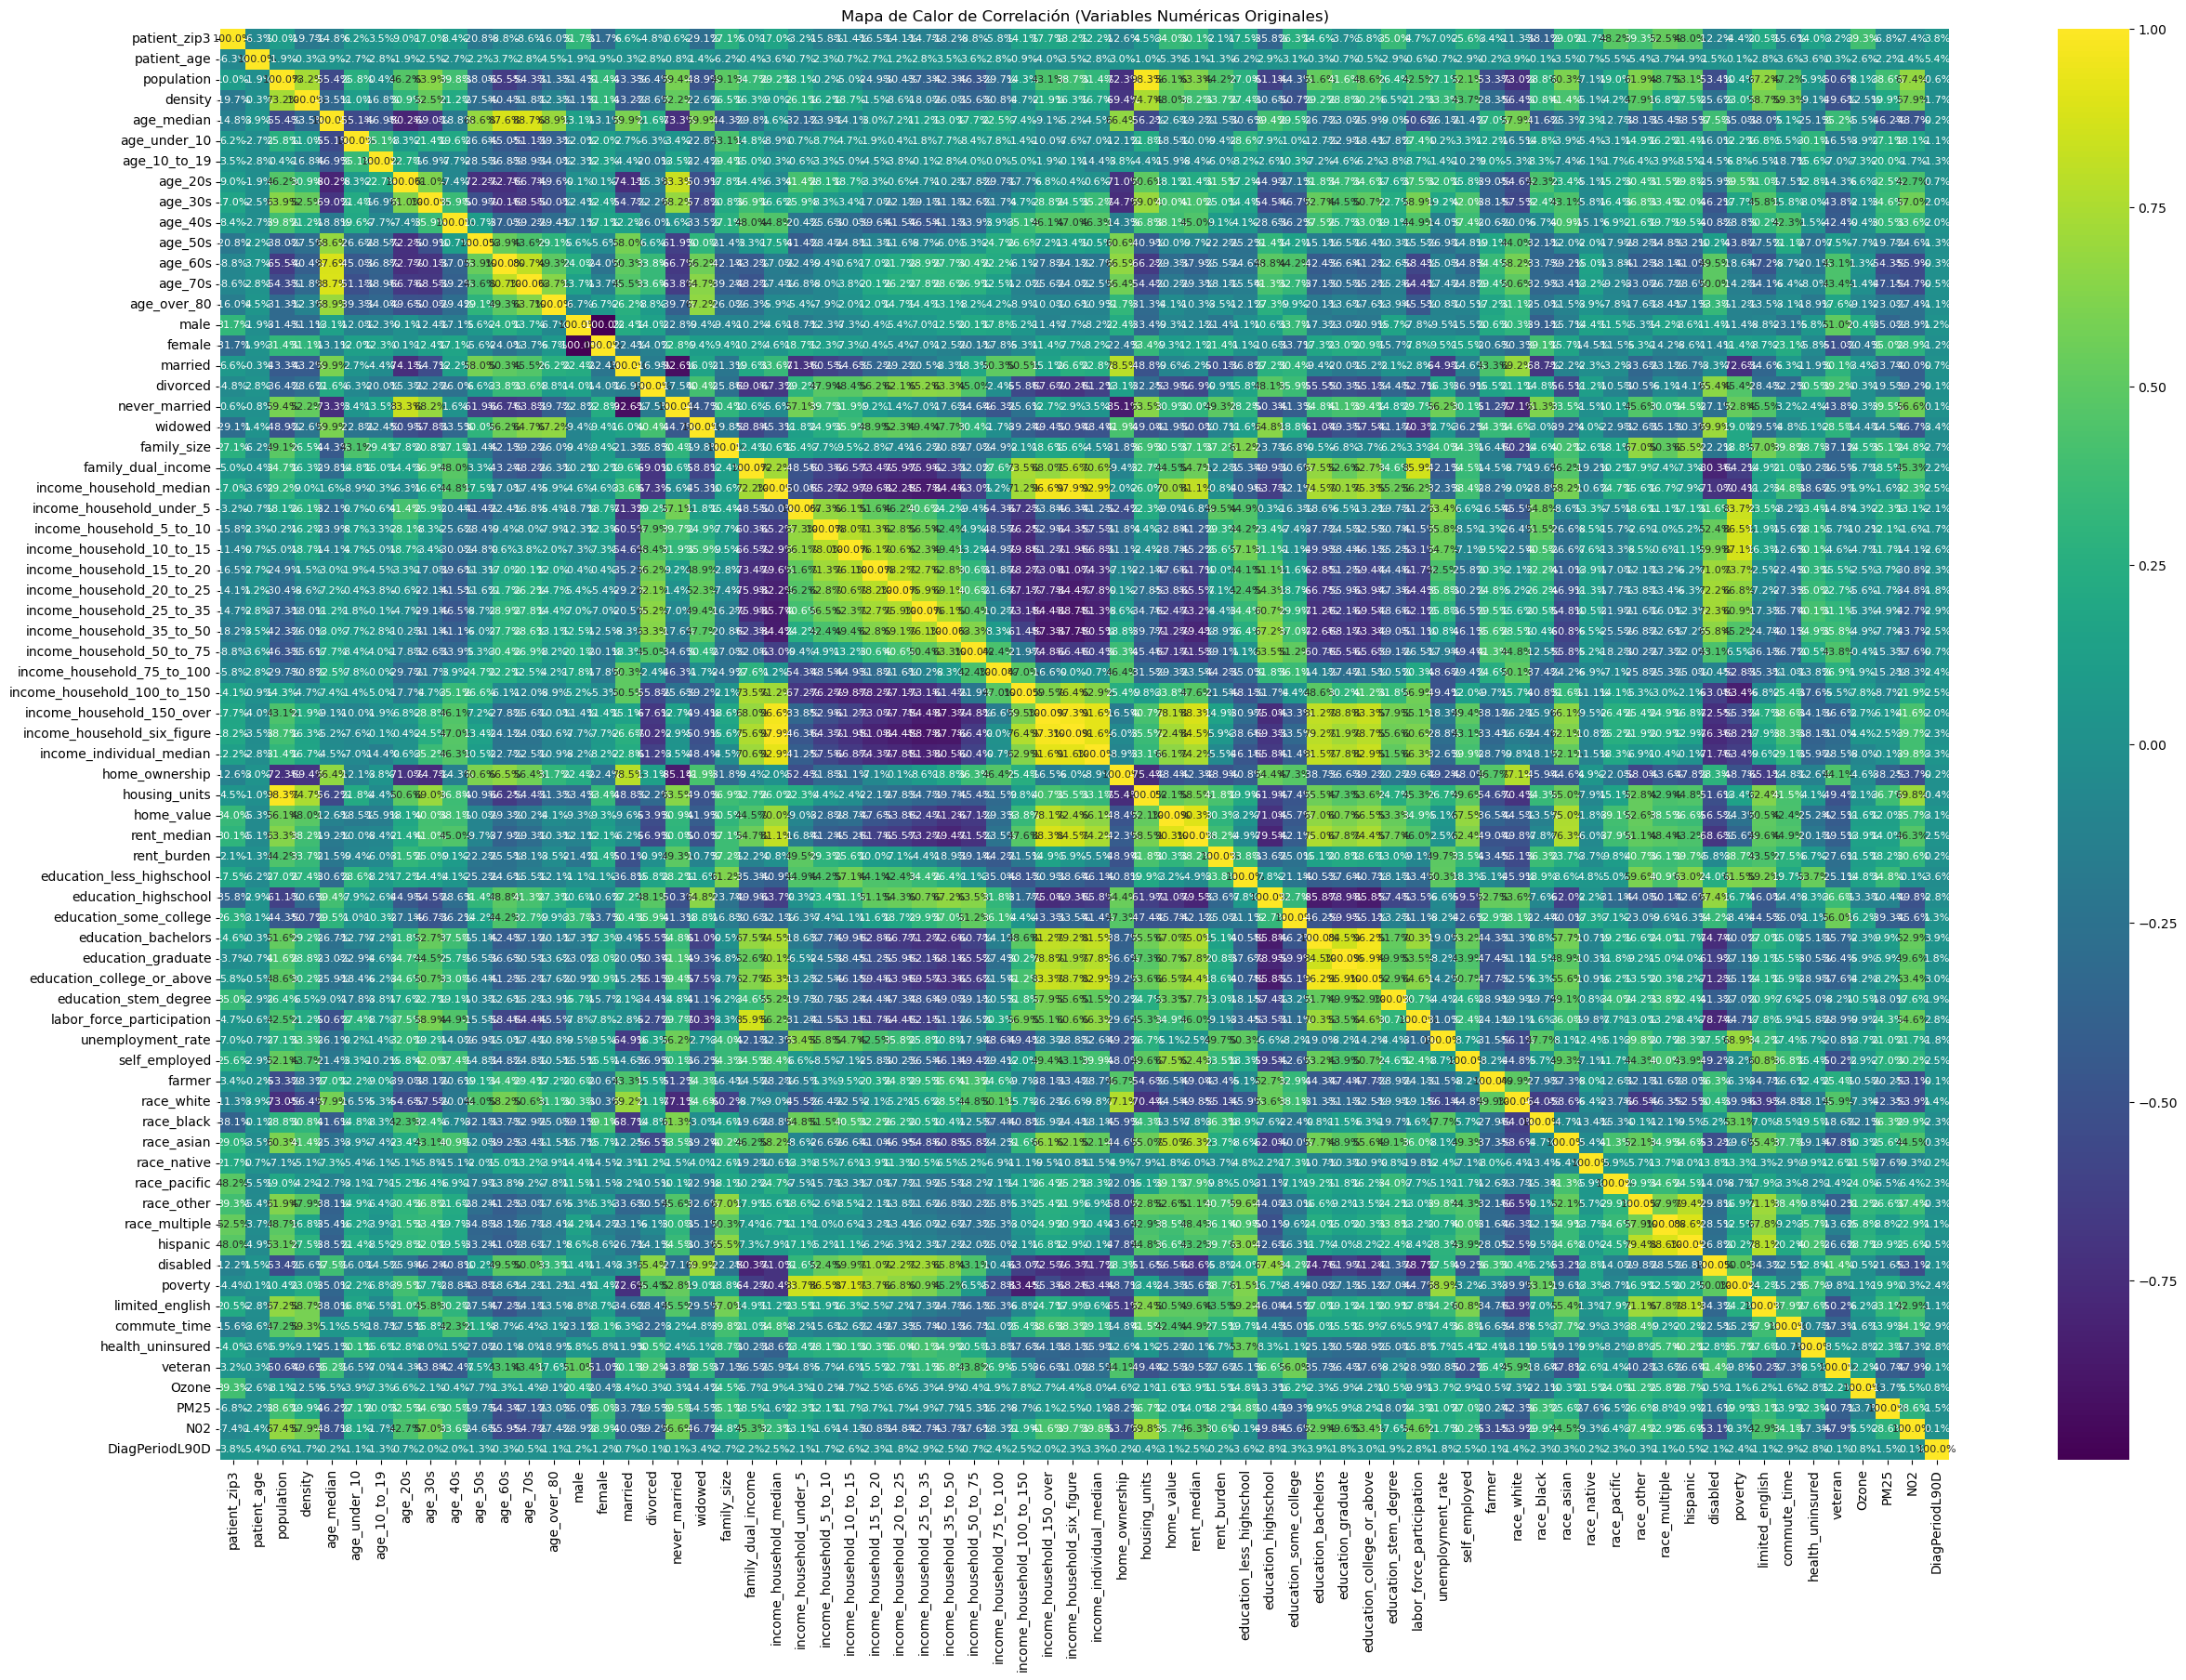

In [35]:
# Usamos el dataframe pre-codificación 'df_training'
numeric_df = df_training.select_dtypes(include='number')

plt.figure(figsize=(30, 20))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".1%", cmap="viridis", annot_kws={"size": 8})
plt.title('Mapa de Calor de Correlación (Variables Numéricas Originales)')
plt.show()

### Selección de Características Categóricas (Chi-Cuadrado)

Para ver si dos variables categóricas están fuertemente asociadas (y por lo tanto son redundantes).

In [36]:
from scipy.stats import chi2_contingency

# Ejemplo: ¿Están 'Region' y 'Division' fuertemente asociadas?
contingency_table = pd.crosstab(df_training['Region'], df_training['Division'])

chi2, p_value, _, _ = chi2_contingency(contingency_table)

print(f"--- Chi2 entre Region y Division ---")
print(f"Chi2 Stat: {chi2:.2f}")
print(f"P-valor: {p_value}")

if p_value < 0.05:
    print("Resultado: Existe una asociación estadísticamente significativa (p < 0.05).")

else:
    print("Resultado: No existe una asociación estadísticamente significativa (p >= 0.05).")

--- Chi2 entre Region y Division ---
Chi2 Stat: 38358.00
P-valor: 0.0
Resultado: Existe una asociación estadísticamente significativa (p < 0.05).


### Análisis de Correlación (Sobre variables codificadas)

In [37]:
umbral_correlacion = 0.8
correlacion_abs = df_normalizado.drop(columns=['DiagPeriodL90D']).corr().abs()
eliminar_caracteristicas = set() # conjunto para almacenar las caracteristicas a eliminar

for i in range(len(correlacion_abs.columns)): # recorrer las columnas y filas y buscar correlaciones altas
  for j in range(i):
    if correlacion_abs.iloc[i, j] > umbral_correlacion:
      colname = correlacion_abs.columns[i]
      eliminar_caracteristicas.add(colname)
      
print("Esta lista de Variables presentan correlacion con otras variables explicativas de mas de un 80%")
print(eliminar_caracteristicas)

Esta lista de Variables presentan correlacion con otras variables explicativas de mas de un 80%
{'housing_units', 'education_graduate', 'female', 'hispanic', 'Division_Middle Atlantic', 'education_college_or_above', 'never_married', 'age_60s', 'income_household_six_figure', 'education_bachelors', 'disabled', 'home_ownership', 'income_household_25_to_35', 'Division_Pacific', 'age_70s', 'rent_median', 'poverty', 'age_20s', 'income_individual_median', 'labor_force_participation', 'income_household_20_to_25', 'Division_East North Central', 'income_household_150_over', 'Division_West South Central', 'Region_Northeast', 'income_household_35_to_50'}


In [38]:
# Crear el df reducido
df_reducido = df_normalizado.drop(columns=list(eliminar_caracteristicas))
print(f"\nDimensiones originales: {df_normalizado.shape}")
print(f"Dimensiones reducidas: {df_reducido.shape}")


Dimensiones originales: (12786, 241)
Dimensiones reducidas: (12786, 215)


## Análisis de Componentes Principales (PCA):

Usaremos el `df_normalizado` que ya tiene todas las variables (numéricas y categóricas OHE) estandarizadas.

In [39]:
# 1. Separar X e y del dataframe normalizado
X_scaled = df_normalizado.drop(columns=['DiagPeriodL90D'])
y_pca = df_normalizado['DiagPeriodL90D']
columnas_pca = X_scaled.columns.tolist()

print(f"Dimensiones de X para PCA sin variable objetivo: {X_scaled.shape}")

Dimensiones de X para PCA sin variable objetivo: (12786, 240)


In [40]:
# 2. Aplicación Inicial de PCA y Descomposición Espectral
pca_full = PCA()
pca_full.fit(X_scaled)

,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [41]:
# 3. Análisis de Varianza Explicada y Selección de Componentes (k)
varianza_explicada = pca_full.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_explicada)

# Determinamos el número óptimo de componentes para capturar el 95% de la varianza.
umbral_varianza = 0.95
n_componentes_optimo = np.argmax(varianza_acumulada >= umbral_varianza) + 1

print(f"Paso 3: Se necesitan {n_componentes_optimo} componentes para explicar el {umbral_varianza*100}% de la varianza.")

Paso 3: Se necesitan 156 componentes para explicar el 95.0% de la varianza.


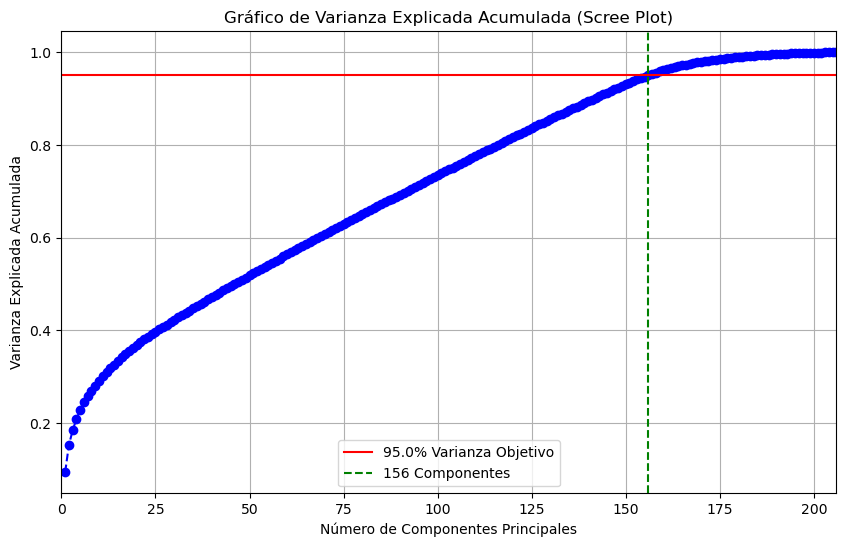

In [42]:
# Visualización del Scree Plot (Varianza Acumulada)
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, marker='o', linestyle='--', color='b')
plt.axhline(y=umbral_varianza, color='r', linestyle='-', label=f'{umbral_varianza*100}% Varianza Objetivo')
plt.axvline(x=n_componentes_optimo, color='g', linestyle='--', label=f'{n_componentes_optimo} Componentes')
plt.title('Gráfico de Varianza Explicada Acumulada (Scree Plot)')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Varianza Explicada Acumulada')
plt.legend()
plt.grid(True)
# Limitar el eje X para mejor visualización
plt.xlim(0, n_componentes_optimo + 50)
plt.show()

In [43]:
# 4. Aplicación Final de PCA y Transformación de Datos
pca_final = PCA(n_components=n_componentes_optimo)
X_pca = pca_final.fit_transform(X_scaled)

print(f"Paso 4: Dimensionalidad original: {X_scaled.shape[1]}. Dimensionalidad reducida: {X_pca.shape[1]}")

Paso 4: Dimensionalidad original: 240. Dimensionalidad reducida: 156


In [44]:
# 5. Interpretación de los Resultados (Cargas factoriales)
loadings = pca_final.components_.T * np.sqrt(pca_final.explained_variance_)
loadings_df = pd.DataFrame(loadings, index=columnas_pca, columns=[f"PC{i+1}" for i in range(n_componentes_optimo)])
print("\nMatriz de Cargas Factoriales (Contribución de cada variable a los componentes):")
display(loadings_df.head(10))


Matriz de Cargas Factoriales (Contribución de cada variable a los componentes):


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC147,PC148,PC149,PC150,PC151,PC152,PC153,PC154,PC155,PC156
patient_zip3,0.254313,-0.014336,0.800324,-0.313476,-0.172065,-0.057402,-0.167408,0.138926,-0.062469,0.071675,...,-0.016243,-0.000298,-0.011354,0.019071,-0.005794,0.023695,0.015565,-0.002529,-0.026217,-0.006798
patient_age,-0.043170,-0.020771,-0.084046,0.045662,-0.113014,-0.032444,0.076587,-0.177190,0.118430,0.204827,...,-0.054758,0.073134,0.046868,-0.028196,-0.022762,0.164989,-0.066989,0.006229,-0.030093,0.036777
population,0.757593,0.401375,-0.076148,0.012771,0.038379,-0.128047,0.070754,-0.156536,-0.120630,0.032728,...,0.020672,-0.011716,-0.005005,-0.028361,0.009259,-0.025106,0.050915,-0.020844,-0.078014,0.027859
density,0.501632,0.414141,-0.283446,0.292601,-0.049199,-0.270148,0.194746,0.027562,-0.033736,0.127508,...,-0.012298,-0.016752,-0.009183,0.057308,-0.036719,-0.036214,0.015349,-0.036343,-0.085748,0.034513
age_median,-0.471250,-0.557520,0.147749,0.584301,0.105279,0.012811,-0.106633,-0.019961,-0.125561,0.141294,...,-0.002025,-0.006931,-0.016436,0.023399,-0.009182,-0.000011,-0.006269,0.003694,0.003744,-0.006345
age_under_10,0.071581,0.225103,-0.116491,-0.570046,0.193827,-0.415461,0.107209,-0.046639,0.054256,-0.085606,...,-0.034038,-0.014797,0.046677,-0.050674,0.080114,-0.012929,-0.030535,0.029071,0.088727,0.010927
age_10_to_19,0.031003,0.113875,-0.057304,-0.474459,0.119888,-0.077677,-0.017691,0.075089,0.202325,-0.324717,...,0.018302,0.042647,0.026725,-0.027670,0.051700,0.049079,0.035879,0.036121,0.090737,0.040081
age_20s,0.414002,0.552963,-0.100612,-0.336797,-0.303746,0.278016,0.104497,0.025605,0.116402,-0.040524,...,0.000861,-0.006082,-0.009627,-0.005982,-0.023450,0.003102,0.048499,-0.027576,-0.099105,0.024319
age_30s,0.633737,0.387152,-0.143647,-0.260817,-0.160857,0.106337,0.095057,-0.003249,-0.002373,0.102597,...,-0.002035,0.002376,-0.005975,0.021037,-0.039818,-0.021987,-0.028749,-0.036087,-0.072932,-0.025419
age_40s,0.508930,-0.105671,-0.075855,-0.090969,0.297995,-0.153214,-0.062043,-0.140125,-0.097905,-0.151435,...,0.049348,-0.004317,0.003274,0.001734,-0.032399,-0.068631,-0.078881,-0.000447,0.076135,-0.060238


### Visualización e Interpretación de PCA: Biplot Mejorado

Este gráfico nos ayuda a entender qué variables originales
contribuyen más a los primeros dos componentes principales (PC1 vs PC2)
y cómo se distribuyen las observaciones (coloreadas por el objetivo).

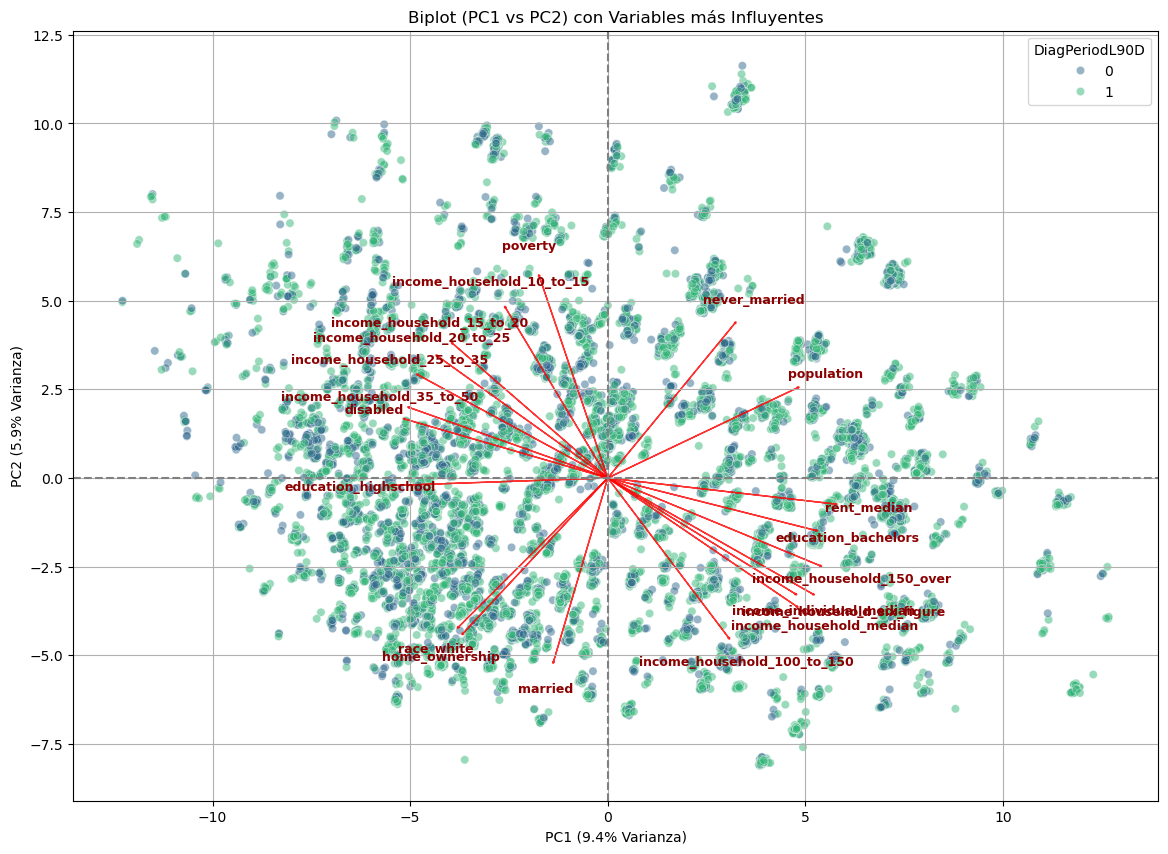

In [45]:
# 1. Scores (ya los tenemos en X_pca)
scores = X_pca

# 2. Loadings (ya los tenemos en 'loadings')

# 3. Varianza explicada (ya la tenemos en 'pca_final.explained_variance_ratio_')
var_exp = pca_final.explained_variance_ratio_
pc1_var = var_exp[0] * 100
pc2_var = var_exp[1] * 100

# 4. Variable objetivo (la tenemos en 'y_pca')

# --- Creación del Biplot ---
plt.figure(figsize=(14, 10))

# A. Gráfico de Scores (Puntos de datos)
# Coloreamos los puntos según la variable objetivo 'DiagPeriodL90D'
sns.scatterplot(x=scores[:, 0], y=scores[:, 1], hue=y_pca, alpha=0.5, palette='viridis')

# B. Gráfico de Loadings (Flechas de variables)
num_variables_a_mostrar = 20 # Mostrar solo las N más influyentes

# Calcular la magnitud de las cargas en PC1 y PC2 para encontrar las más influyentes
magnitudes = np.sqrt(loadings[:, 0]**2 + loadings[:, 1]**2)
indices_top = np.argsort(magnitudes)[-num_variables_a_mostrar:]

# Factor de escala para las flechas (para que se vean bien)
arrow_scale = np.max(np.abs(scores[:, :2])) * 0.5 

for i in indices_top:
    x_arrow, y_arrow = loadings[i, 0], loadings[i, 1]
    var_name = columnas_pca[i]
    
    # Dibujar la flecha
    plt.arrow(0, 0, x_arrow * arrow_scale, y_arrow * arrow_scale,
              head_width=0.05, head_length=0.05,
              color='red', alpha=0.8)
    
    # Etiquetar la variable
    plt.text(x_arrow * arrow_scale * 1.15, y_arrow * arrow_scale * 1.15, var_name,
             ha='center', va='center',
             fontsize=9, color='darkred', fontweight='bold')

# C. Estilo del gráfico
plt.axhline(0, color='grey', linestyle='--')
plt.axvline(0, color='grey', linestyle='--')
plt.xlabel(f"PC1 ({pc1_var:.1f}% Varianza)")
plt.ylabel(f"PC2 ({pc2_var:.1f}% Varianza)")
plt.title("Biplot (PC1 vs PC2) con Variables más Influyentes")
plt.legend(title='DiagPeriodL90D')
plt.grid(True)
plt.show()

#### Interpretar

1.  **Flechas (Variables):**
    * **Dirección:** Flechas que apuntan en la misma dirección indican variables positivamente correlacionadas. Flechas en direcciones opuestas están negativamente correlacionadas.
    * **Longitud:** Flechas más largas tienen una mayor influencia en estos dos componentes (y, por tanto, explican más varianza).
2.  **Puntos (Observaciones):**
    * Muestran cómo se agrupan tus observaciones.


### Pasar scores de PCA (array) a un DataFrame para Modelado

In [46]:
# 1. Determinar el número de componentes (columnas en X_pca)
num_componentes = X_pca.shape[1]

# 2. Crear los nombres de las columnas (PC1, PC2, PC3, ...)
nombres_columnas = [f"PC{i+1}" for i in range(num_componentes)]

# 3. Convertir el array a DataFrame
df_predictores_pca = pd.DataFrame(
  data=X_pca,
  columns=nombres_columnas
)

# Este DataFrame 'df_predictores_pca' y la serie 'y_pca' están listos para ML.
print("Nuevos predictores (Scores de PCA) listos para ML:")
display(df_predictores_pca.head())

Nuevos predictores (Scores de PCA) listos para ML:


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC147,PC148,PC149,PC150,PC151,PC152,PC153,PC154,PC155,PC156
0,1.601411,8.360866,4.155830,-2.501648,-0.664255,-4.402260,0.285196,-2.087549,2.072154,-1.885825,...,-0.535538,0.635088,-0.753699,0.241055,0.264683,0.558215,-0.460679,1.673029,0.347704,-0.490117
1,7.121845,-1.262618,2.801953,-0.319500,0.594251,-1.557571,-1.473942,-0.245562,0.320595,-1.359217,...,0.025638,0.007941,-0.437212,-0.289531,-0.096133,-0.707299,0.667988,-0.383955,0.486724,-0.066014
2,0.756867,-1.571925,0.375198,-3.888555,3.943970,-0.128185,1.517261,0.496493,-0.508896,-0.675450,...,-1.297034,-0.752747,-1.329811,0.109143,-0.093327,-0.520561,-0.009747,-0.708741,-0.148597,-0.439007
3,7.966877,-3.917409,2.002884,2.266953,-0.175552,1.803051,-2.487939,1.813808,-0.256749,0.131645,...,-0.310221,-0.538076,0.018174,-0.269968,0.218717,-0.497207,1.145255,-0.341933,-0.027273,-0.298757
4,-5.031504,-2.496986,4.384734,-1.057525,-0.425166,-0.212415,3.250211,0.936449,-1.635873,-1.174791,...,1.141744,0.060616,-1.425784,-0.125250,1.110451,-1.102296,-0.481085,-0.098403,-0.192889,-0.339472


In [47]:
print("Variable objetivo lista para ML:")
display(y_pca.head())

Variable objetivo lista para ML:


0    1
1    1
2    1
3    0
4    0
Name: DiagPeriodL90D, dtype: int64

# Conclusiones:

### Principales Hallazgos:

- El problema principal es un desequilibrio de clases (37-63) en la variable objetivo
- Las variables demográficas y socioeconómicas parecen ser predictores más fuertes que las ambientale.
- Existen outlies en los datos, se podria aplicar algun tratamiento como log nat a los datos 


## Variables más útiles  :

patient_race, payer_type, Region, Division:Claves para el análisis de equidad y mostraron diferencias en las tasas de diagnóstico.

bmi_category:La creamos a partir de bmi para manejar nulos y agrupar.

patient_age:Mostro una diferencia de distribucioon clara.

income_household_medianypoverty:Variables socioeconómicas que muestran una ligera separación.

### Transformaciones Aplicadas:

- Se eliminaron las filas que tenian poco porcentaje de nulos 

- Codificación:Se usóCodificación one-hot(pd.get_dummies) para todas las variables categóricas,lo que expandió el número de columnas.

- Normalización (Escalado):Se aplicó Standard Scaler a todaslas variables predictoras.

- Reducción de Dimensionalidad:Se aplicó PCA(Análisis de Componentes Principales) para reducir la dimensionalidad. Dimensionalidad original: 240. Dimensionalidad reducida: 156